# Master Seminar on Econometrics
## Using Google Search Data to Nowcast German Unemployment

Name : Alexander Unger
Matrikelnummer : 6946672


### Data import and initial preprocessing: Google Trends (weekly)

This cell loads the raw weekly Google Trends series for all keywords considered in the analysis: *indeed*, *stepstone*, *jobbörse*, *arbeitsamt*, and *bewerbung*.  
For each keyword, three separate CSV files are imported, corresponding to non-overlapping time windows. This split reflects Google Trends’ export limitation on maximum query length and is standard practice when constructing long historical series.

To ensure consistency across keywords and files, the following preprocessing steps are applied uniformly:

- Column names are standardized so that each dataset contains a `Date` column and a single keyword-specific index.
- The `Date` column is converted to a proper `datetime` format to allow time-based merging and alignment.
- All Google Trends values are coerced to numeric format, with non-numeric entries safely converted to missing values.

At this stage, the data remain at the **weekly frequency** and are not yet merged across subperiods or transformed. Subsequent steps will concatenate the subseries for each keyword, align them on a common weekly index, and construct the predictors used in the biweekly ARX and U-MIDAS specifications.


In [1]:
import pandas as pd

# indeed data
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

# stepstone data
stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

# bewerbung data 
Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

# arbeitsamt data
arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

# jobbörse data 
jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)

## Define the columns for all
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]


for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")


### Constructing consistent weekly Google Trends series (stitching and rescaling)

Google Trends exports are constrained in length, so each keyword is downloaded in three non-overlapping windows (`w1`, `w2`, `w3`). Because Google Trends is normalized *within each export window*, the levels across windows are not directly comparable. This cell therefore constructs a single consistent weekly time series per keyword by **rescaling and stitching** the three subseries.

The procedure is as follows:

- `_prep()` cleans each window: parses dates, enforces numeric values, drops missing observations, sets a time index, and sorts chronologically.
- `_median_ratio()` computes a robust scaling factor using the **median ratio** on overlapping dates (when overlap exists). Using the median (rather than the mean) reduces sensitivity to outliers and short-lived spikes in search intensity.
- `stitch_three()` applies two sequential rescalings:
  - window 2 is rescaled to match window 1 on the overlap,
  - window 3 is rescaled to match the (already rescaled) window 2 on the overlap,
  and then concatenates the windows while removing duplicate dates.

After stitching, each keyword series is restricted to a common weekly sample (`START` to `END_WEEK`) and checked for a strictly weekly (7-day) step size to ensure a clean weekly index. Finally, the five keyword series are merged into a single weekly panel `df_week`, which serves as the high-frequency input for the U-MIDAS specifications and for constructing lower-frequency aggregates in the ARX models.


In [2]:
import numpy as np

# Here I select the sunday timestep
START = pd.Timestamp("2011-05-01")      
END_WEEK = pd.Timestamp("2023-01-29")   
END_MONTH = pd.Timestamp("2023-01-31")  

def _prep(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df[["Date", value_col]].copy()
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce").dt.tz_localize(None)
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return out

def _median_ratio(a: pd.Series, b: pd.Series) -> float:
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    return float(np.median((x[mask] / y[mask]).values)) if mask.sum() else 1.0

def stitch_three(w1: pd.DataFrame, w2: pd.DataFrame, w3: pd.DataFrame,
                 value_col: str, final_name: str | None = None) -> pd.DataFrame:
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    # rescaling W2
    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2.copy()
    W2r[value_col] = W2r[value_col] * s21

    # rescaling W3
    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3.copy()
    W3r[value_col] = W3r[value_col] * s32

    # concatenate without duplicate dates 
    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()


    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    name = final_name or value_col
    out = out.rename(columns={value_col: name}).reset_index().rename(columns={"index": "Date"})
    return out


indeed     = stitch_three(indeed_w1, indeed_w2, indeed_w3, "indeed")
stepstone  = stitch_three(stepstone_w1, stepstone_w2, stepstone_w3, "stepstone")
bewerbung  = stitch_three(Bewerbung_w1, Bewerbung_w2, Bewerbung_w3, "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt")
jobboerse  = stitch_three(jobbörse_w1, jobbörse_w2, jobbörse_w3, "jobbörse")

# my sanity
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobboerse), ("arbeitsamt", arbeitsamt), ("bewerbung", bewerbung)]:
    if not (d["Date"].diff().dropna().dt.days == 7).all():
        raise ValueError(f"{name}: not strictly weekly (7-day steps)")
    

# creating one big weekly dataset
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobboerse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(bewerbung,  on="Date", how="inner"))


In [3]:
df_week.head()


,Date,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
0,2011-05-01,49.0,14.0,75.0,86.0,63.0
1,2011-05-08,50.0,14.0,80.0,84.0,68.0
2,2011-05-15,52.0,14.0,80.0,87.0,73.0
3,2011-05-22,52.0,15.0,80.0,83.0,73.0
4,2011-05-29,42.0,13.0,69.0,73.0,60.0


**(sanity check)**
Each row corresponds to a **Sunday week-ending date**, and each column contains the rescaled Google Trends index for one keyword (*stepstone*, *indeed*, *jobbörse*, *arbeitsamt*, *bewerbung*).

This check confirms that:

- All keyword series are successfully aligned on a common weekly calendar.
- The stitching and rescaling procedure yields plausible, smoothly evolving weekly indices.
- No missing values remain after merging, ensuring that the panel is suitable for mixed-frequency regression and aggregation.

The resulting weekly panel forms the basis for constructing biweekly aggregates and for extracting weekly lags in the U-MIDAS specifications used in the nowcasting exercise.


### Parsing Bundesagentur für Arbeit release dates and importing monthly unemployment

To implement a publication-based pseudo real-time nowcasting design, the analysis requires month-specific publication dates. This cell defines a parser that extracts the Bundesagentur für Arbeit (BA) release schedule from the official PDF archive and converts it into a structured table.

**Release schedule parsing (`parse_ba_release_schedule_from_pdf`)**

- The PDF schedule contains, for each calendar month, both a *Stichtag* and the *release date* of the monthly unemployment figure.
- The function reads the PDF page-by-page and uses regular expressions to identify (i) the year header and (ii) month-specific lines containing the two relevant dates.
- The resulting dataset is indexed by the **Berichtsmonat** (month \(t\)) using a month-end timestamp, with two columns:
  - `stichtag`: the reference date used in the BA reporting process,
  - `release`: the official publication date for the month-\(t\) unemployment figure.

These dates are used later to define the month-specific cutoff that determines which weekly Google Trends observations are admissible in the information set for predicting month \(t\).

**Monthly unemployment data import**

- The unemployment rate series is imported from CSV, cleaned, and converted to a month-end indexed time series.
- The sample is restricted to a common analysis window (May 2011 through January 2023) to match the weekly Google Trends panel.

At the end of this step, the notebook contains:
- a monthly unemployment series `unemp` indexed at month-end, and
- a release schedule table (constructed later by calling the parser) that supports pseudo real-time forecast timing.


In [4]:
import re
import pandas as pd

def parse_ba_release_schedule_from_pdf(pdf_path: str) -> pd.DataFrame:
    """
    Parse the Bundesagentur für Arbeit schedule PDF (archive) into a table:
    index  = month-end timestamp of Berichtsmonat (Period M -> month end)
    cols   = ['stichtag', 'release'] as pd.Timestamp (date only, time omitted)

    Requires: pdfplumber (pip install pdfplumber)
    """
    import pdfplumber  # local import so your notebook only needs it when used

    month_map = {
        "Januar": 1, "Februar": 2, "März": 3, "Maerz": 3, "April": 4, "Mai": 5, "Juni": 6,
        "Juli": 7, "August": 8, "September": 9, "Oktober": 10, "November": 11, "Dezember": 12
    }

    # Match lines like:
    # "Januar Donnerstag, 12.01.2023 Dienstag, 31.01.2023"
    # Allow missing spaces after commas (seen in the PDF for some years).
    line_pat = re.compile(
        r"^(Januar|Februar|März|Maerz|April|Mai|Juni|Juli|August|September|Oktober|November|Dezember)\s+"
        r".*?,\s*(\d{2}\.\d{2}\.\d{4})\s+"
        r".*?,\s*(\d{2}\.\d{2}\.\d{4})\s*$"
    )

    year_pat = re.compile(r"Jahr\s+(20\d{2})")

    rows = []
    current_year = None

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text() or ""
            for raw in text.splitlines():
                s = " ".join(raw.strip().split())  # normalize whitespace

                # update current year when header appears
                ym = year_pat.search(s)
                if ym:
                    current_year = int(ym.group(1))

                m = line_pat.match(s)
                if m and current_year is not None:
                    mon_name = m.group(1)
                    st_str = m.group(2)
                    rel_str = m.group(3)

                    mon_num = month_map[mon_name]
                    st = pd.to_datetime(st_str, format="%d.%m.%Y")
                    rel = pd.to_datetime(rel_str, format="%d.%m.%Y")

                    # Index by Berichtsmonat month-end
                    month_end = pd.Period(f"{current_year}-{mon_num:02d}", freq="M").to_timestamp("M")

                    rows.append({"month_end": month_end, "stichtag": st, "release": rel})

    out = pd.DataFrame(rows).drop_duplicates(subset=["month_end"]).set_index("month_end").sort_index()
    out.index = pd.to_datetime(out.index).tz_localize(None)
    out["stichtag"] = pd.to_datetime(out["stichtag"]).dt.tz_localize(None)
    out["release"] = pd.to_datetime(out["release"]).dt.tz_localize(None)
    return out


In [5]:
unemp = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=",").copy()
unemp.columns = ["Date", "Unemp"]  
unemp["Date"] = pd.to_datetime(unemp["Date"], errors="coerce").dt.tz_localize(None)
unemp["Unemp"] = pd.to_numeric(unemp["Unemp"], errors="coerce")

# structurized the data
unemp = (unemp.dropna(subset=["Date", "Unemp"])
              .set_index("Date")
              .sort_index())


unemp.index = unemp.index.to_period("M").to_timestamp("M")

# defined the same timeframe
unemp = unemp.loc["2011-05-31":"2023-01-31"]

### Constructing the month-specific publication cutoff (release dates)

This cell operationalizes the publication-based information set by mapping BA release dates to the monthly unemployment index.

Steps:

- The BA release schedule is parsed from the archive PDF and stored in `schedule`, indexed by the month-end of the corresponding **Berichtsmonat**.
- The unemployment series `U` is aligned to a month-end timestamp index to match the schedule indexing.
- A month-specific cutoff series `cutoff_release` is created by reindexing the schedule to the unemployment month-ends and extracting the `release` date for each month.

A consistency check then identifies months for which the parser did not extract a release date. In this dataset, the missing entries occur systematically for October in several years. To preserve a complete pseudo real-time evaluation sample, these release dates are patched manually using known BA publication dates from the archive.

The resulting `cutoff_release` series provides the release-date cutoff used later to define  i.e., the last admissible weekly Google Trends observation strictly prior to the official publication of the month-\(t\) unemployment figure.


In [6]:
schedule = parse_ba_release_schedule_from_pdf("Veroeffentlichungstermine-Archiv.pdf")

# Align schedule to your unemployment series month-ends
U = unemp["Unemp"].copy()
U.index = pd.to_datetime(U.index).tz_localize(None)
U.index = U.index.to_period("M").to_timestamp("M")

cutoff_release = schedule.reindex(U.index)["release"].copy()
cutoff_release = pd.to_datetime(cutoff_release).dt.tz_localize(None).dt.normalize()

In [7]:
missing = cutoff_release[cutoff_release.isna()].index
print("Missing release months:", missing)


Missing release months: DatetimeIndex(['2011-10-31', '2012-10-31', '2013-10-31', '2014-10-31',
               '2015-10-31', '2016-10-31'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [8]:
# (A) Patch missing October release dates (from BA archive PDF)
release_patch = {
    pd.Timestamp("2011-10-31"): pd.Timestamp("2011-11-02"),
    pd.Timestamp("2012-10-31"): pd.Timestamp("2012-10-30"),
    pd.Timestamp("2013-10-31"): pd.Timestamp("2013-10-30"),
    pd.Timestamp("2014-10-31"): pd.Timestamp("2014-10-30"),
    pd.Timestamp("2015-10-31"): pd.Timestamp("2015-10-29"),
    pd.Timestamp("2016-10-31"): pd.Timestamp("2016-11-02"),
}

cutoff_release = cutoff_release.copy()
for k, v in release_patch.items():
    if k in cutoff_release.index and pd.isna(cutoff_release.loc[k]):
        cutoff_release.loc[k] = v


### Constructing biweekly Google Trends aggregates relative to the BA release date

This cell constructs the monthly-frequency Google Trends predictors used in the ARX specifications by aggregating the weekly series into two biweekly windows, following the timing logic in Askitas and Zimmermann (2009) but implemented under a publication-based information set.

**Key idea (publication-based cutoff).**  
For each month \(t\), the forecast is formed using weekly information available strictly before the official release date \(r_t\). The code therefore identifies the last Sunday (week-ending date) observed before \(r_t\) and restricts the weekly aggregation windows to avoid including search activity occurring on the release date itself.

**Implementation details.**

- `last_sunday_leq()` finds the most recent Sunday in the weekly index that is admissible under the release-date cutoff.
- `build_biweekly_from_release()` loops over months and constructs two monthly predictors per keyword:

  1. **\(W12_t\)**: the mean of weekly search intensity within month \(t\) from the beginning of the month up to the earlier of:
     - day 15 (calendar midpoint), and
     - the last admissible Sunday before the release cutoff \(r_t\).

  2. **\(W34_{t-1}\)**: the mean of weekly search intensity in month \(t-1\) from day 16 to the last admissible Sunday before the *previous* month’s release date \(r_{t-1}\).
     This window is designed to be largely insulated from contemporaneous reactions to the publication of \(U_{t-1}\).

- The `keep_first_month=True` option allows the first month in the sample to be retained even though \(W34_{t-1}\) is undefined for \(t\) at the start of the series (hence the initial `NaN` entries).

The final output `biweekly` is a monthly panel indexed by month-end with 10 predictors (two timing windows for each of five keywords). The printed head/tail and the shape check confirm that the biweekly feature panel is successfully created and aligned over the analysis w


In [9]:
import pandas as pd
import numpy as np

def last_sunday_leq(idx: pd.DatetimeIndex, t: pd.Timestamp) -> pd.Timestamp | None:
    """Return max Sunday in idx with date <= t."""
    t = pd.to_datetime(t)
    eligible = idx[idx <= t]
    return eligible.max() if len(eligible) else None

def build_biweekly_from_release(df_week: pd.DataFrame,
                                cutoff_release: pd.Series,
                                cols: list[str],
                                keep_first_month: bool = True) -> pd.DataFrame:
    wk = df_week.copy()
    wk["Date"] = pd.to_datetime(wk["Date"])
    wk = wk.set_index("Date").sort_index()

    cutoff = cutoff_release.copy()
    cutoff.index = pd.to_datetime(cutoff.index).to_period("M").to_timestamp("M")
    cutoff = cutoff.sort_index().dropna()

    w12_rows, w34_rows, out_idx = [], [], []

    for t in cutoff.index:
        p_t = pd.to_datetime(cutoff.loc[t])

        # use just-before-release cutoff to avoid "on release" reaction contamination
        p_t_minus = p_t - pd.Timedelta(seconds=1)

        # last available weekly obs for month t nowcast
        last_sun_t = last_sunday_leq(wk.index, p_t_minus)
        if last_sun_t is None:
            continue

        # Month t boundaries
        m_start = (t.to_period("M").to_timestamp("M") - pd.offsets.MonthBegin(1)).normalize()
        m_mid_end = (m_start + pd.Timedelta(days=14))  # day 15 end (calendar)
        w12_end = min(last_sun_t, m_mid_end)

        # W12(t): weeks in month t up to min(15th, last_sun_t)
        w12_t = wk.loc[(wk.index >= m_start) & (wk.index <= w12_end), cols].mean()

        # W34prev(t): month t-1, days 16..(day before release_{t-1})
        t_prev = t - pd.offsets.MonthEnd(1)

        if t_prev not in cutoff.index:
            if keep_first_month:
                w34_prev_t = pd.Series({c: np.nan for c in cols})
            else:
                continue
        else:
            p_prev = pd.to_datetime(cutoff.loc[t_prev])
            p_prev_minus = p_prev - pd.Timedelta(seconds=1)

            last_sun_prev_release = last_sunday_leq(wk.index, p_prev_minus)
            if last_sun_prev_release is None:
                if keep_first_month:
                    w34_prev_t = pd.Series({c: np.nan for c in cols})
                else:
                    continue
            else:
                prev_start = (t_prev.to_period("M").to_timestamp("M") - pd.offsets.MonthBegin(1)).normalize()
                prev_mid_start = prev_start + pd.Timedelta(days=15)  # day 16 start

                # cap at last Sunday before release_{t-1}
                w34_prev_t = wk.loc[(wk.index >= prev_mid_start) & (wk.index <= last_sun_prev_release), cols].mean()

        w12_rows.append(w12_t)
        w34_rows.append(w34_prev_t)
        out_idx.append(t)

    w12 = pd.DataFrame(w12_rows, index=pd.DatetimeIndex(out_idx))
    w12.columns = [c + "_W12" for c in cols]

    w34 = pd.DataFrame(w34_rows, index=pd.DatetimeIndex(out_idx))
    w34.columns = [c + "_W34prev" for c in cols]

    return pd.concat([w12, w34], axis=1).sort_index()


In [10]:
cols = ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
biweekly = build_biweekly_from_release(df_week, cutoff_release, cols, keep_first_month=True)


# Here I select my window
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

# check what I done
print(" Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)


 Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5               47.0            14.0   
2011-07-31           86.5               51.5            15.0   
2011-08-31           73.0               51.5            15.5   
2011-09-30           73.5               54.0            15.5   

            jobbörse_W34prev  arbeitsamt_W34prev  bewerbung_W34prev  
2011-05-31               NaN                 NaN                NaN  
2011-06-30     

###  Debugging the construction of the \(W34_{t-1}\) window

This cell is a diagnostic tool used to verify that the \(W34_{t-1}\) aggregation window is constructed correctly under the publication-based cutoff. It is not required for the main analysis, but it provides transparency on how the biweekly predictors are formed and helps explain why some early-sample values may be missing.

The function `debug_w34prev_for_month()` inspects a given month \(t\) and prints:

- the previous month \(t-1\),
- the official release date \(r_{t-1}\) and the effective cutoff just before release \((r_{t-1}-\varepsilon)\),
- the last admissible Sunday week-ending date before that cutoff,
- the start and end dates of the \(W34_{t-1}\) window (day 16 of month \(t-1\) through the last admissible Sunday),
- the number of weekly observations included in the window, and (optionally) the raw weekly values used in the mean.

This diagnostic is useful for confirming that missing \(W34_{t-1}\) values (when they occur) are driven by an empty admissible window under the release-date cutoff, rather than by parsing errors or misalignment of the weekly index.


In [11]:
import pandas as pd
import numpy as np

def debug_w34prev_for_month(df_week, cutoff_release, t, cols=None):
    """
    Debug für einen Monat t (month-end Timestamp, z.B. '2015-08-31'):
    zeigt Release(t-1), last Sunday <= Release(t-1)-1s, und ob W34prev(t) leer ist.
    """
    wk = df_week.copy()
    wk["Date"] = pd.to_datetime(wk["Date"], errors="coerce").dt.tz_localize(None)
    wk = wk.dropna(subset=["Date"]).set_index("Date").sort_index()

    cutoff = pd.to_datetime(cutoff_release).dt.tz_localize(None).dt.normalize().copy()
    cutoff.index = pd.to_datetime(cutoff.index).to_period("M").to_timestamp("M")
    cutoff = cutoff.sort_index()

    t = pd.to_datetime(t).to_period("M").to_timestamp("M")

    # t-1
    t_prev = t - pd.offsets.MonthEnd(1)
    if t_prev not in cutoff.index or pd.isna(cutoff.loc[t_prev]):
        print(f"[{t.date()}] Kein cutoff für t_prev={t_prev.date()}")
        return

    p_prev = cutoff.loc[t_prev]
    p_prev_minus = p_prev - pd.Timedelta(seconds=1)

    # last Sunday <= p_prev_minus
    eligible = wk.index[wk.index <= p_prev_minus]
    last_sun_prev_release = eligible.max() if len(eligible) else None

    prev_start = (t_prev.to_period("M").to_timestamp("M") - pd.offsets.MonthBegin(1)).normalize()
    prev_mid_start = prev_start + pd.Timedelta(days=15)  # Tag 16 (00:00)

    print("==== Debug W34prev(t) ====")
    print("t (month end):            ", t.date())
    print("t_prev (month end):       ", t_prev.date())
    print("release(t_prev):          ", p_prev, "(normalized date)")
    print("p_prev_minus:             ", p_prev_minus)
    print("last_sunday<=p_prev_minus:", None if last_sun_prev_release is None else last_sun_prev_release.date())
    print("W34 window start:         ", prev_mid_start.date(), "(day 16)")
    print("W34 window end:           ", None if last_sun_prev_release is None else last_sun_prev_release.date())

    if last_sun_prev_release is None:
        print("-> Kein Sunday verfügbar vor release(t_prev).")
        return

    mask = (wk.index >= prev_mid_start) & (wk.index <= last_sun_prev_release)
    n = int(mask.sum())
    print("n weekly obs in window:   ", n)

    if n == 0:
        print("-> Fenster ist LEER => mean() wird NaN (kein Parsing-Fehler).")
        # Extra Erklärung: last Sunday liegt vor Tag 16?
        print("   last_sunday < day16 ?  ", last_sun_prev_release < prev_mid_start)
        # Und wo liegt last Sunday?
        print("   last_sunday month:     ", last_sun_prev_release.strftime("%Y-%m"))
        print("   t_prev month:          ", t_prev.strftime("%Y-%m"))
    else:
        # optional: zeige die Datenpunkte
        show = wk.loc[mask, cols] if cols is not None else wk.loc[mask]
        print(show)
        print("-> Fenster NICHT leer; mean wäre definiert.")


In [12]:
cols = ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]

debug_w34prev_for_month(df_week, cutoff_release, "2015-09-30", cols=cols)
debug_w34prev_for_month(df_week, cutoff_release, "2016-02-29", cols=cols)
debug_w34prev_for_month(df_week, cutoff_release, "2011-06-30", cols=cols)


==== Debug W34prev(t) ====
t (month end):             2015-09-30
t_prev (month end):        2015-08-31
release(t_prev):           2015-09-01 00:00:00 (normalized date)
p_prev_minus:              2015-08-31 23:59:59
last_sunday<=p_prev_minus: 2015-08-30
W34 window start:          2015-08-16 (day 16)
W34 window end:            2015-08-30
n weekly obs in window:    3
            stepstone  indeed  jobbörse  arbeitsamt  bewerbung
Date                                                          
2015-08-16       71.0    81.0      70.0        56.0       68.0
2015-08-23       70.0    81.0      74.0        55.0       70.0
2015-08-30       77.0    82.0      83.0        57.0       69.0
-> Fenster NICHT leer; mean wäre definiert.
==== Debug W34prev(t) ====
t (month end):             2016-02-29
t_prev (month end):        2016-01-31
release(t_prev):           2016-02-02 00:00:00 (normalized date)
p_prev_minus:              2016-02-01 23:59:59
last_sunday<=p_prev_minus: 2016-01-31
W34 window start:    

### Sanity checks for selected months

The debug function is evaluated for a small set of representative months (including early-sample months and months with short release lags). For each case, the output confirms that:

- the cutoff is applied strictly prior to the release date,
- the last admissible Sunday is correctly identified,
- the \(W34_{t-1}\) window contains the expected number of weekly observations,
- and the computed biweekly mean is well-defined whenever the window is non-empty.

These checks support the correctness of the publication-based biweekly aggregation used in the ARX timing comparison.


In [13]:
import pandas as pd

def debug_w12(df_week: pd.DataFrame, cutoff_release: pd.Series, cols, t: str | pd.Timestamp):
    wk = df_week.copy()
    wk["Date"] = pd.to_datetime(wk["Date"])
    wk = wk.set_index("Date").sort_index()

    cutoff = cutoff_release.copy()
    cutoff.index = pd.to_datetime(cutoff.index).to_period("M").to_timestamp("M")
    cutoff = cutoff.sort_index()

    t = pd.to_datetime(t).to_period("M").to_timestamp("M")

    if t not in cutoff.index or pd.isna(cutoff.loc[t]):
        print(f"[W12 DEBUG] t={t.date()} hat kein release-Datum in cutoff_release.")
        return

    p_t = pd.to_datetime(cutoff.loc[t])
    p_t_minus = p_t - pd.Timedelta(seconds=1)

    eligible = wk.index[wk.index <= p_t_minus]
    last_sun_t = eligible.max() if len(eligible) else None

    m_start = (t.to_period("M").to_timestamp("M") - pd.offsets.MonthBegin(1)).normalize()
    m_mid_end = m_start + pd.Timedelta(days=14)
    w12_end = None if last_sun_t is None else min(last_sun_t, m_mid_end)

    if last_sun_t is None:
        n = 0
        w12_slice = wk.iloc[0:0][cols]
    else:
        w12_slice = wk.loc[(wk.index >= m_start) & (wk.index <= w12_end), cols]
        n = len(w12_slice)

    print("==== Debug W12(t) ====")
    print(f"t (month end):             {t.date()}")
    print(f"release(t):                {p_t} (normalized date)")
    print(f"p_t_minus:                 {p_t_minus}")
    print(f"last_sunday<=p_t_minus:    {None if last_sun_t is None else last_sun_t.date()}")
    print(f"W12 window start:          {m_start.date()} (month start)")
    print(f"W12 mid cutoff (day15):    {m_mid_end.date()}")
    print(f"W12 window end:            {None if w12_end is None else w12_end.date()} (min(last_sun, day15))")
    print(f"n weekly obs in window:    {n}")

    if n > 0:
        print(w12_slice)
        print("-> Fenster NICHT leer; mean wäre definiert.")
    else:
        print("-> Fenster LEER; mean wäre NaN.")


In [14]:
cols = ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]

debug_w12(df_week, cutoff_release, cols, "2015-09-30")
debug_w12(df_week, cutoff_release, cols, "2016-02-29")
debug_w12(df_week, cutoff_release, cols, "2011-06-30")


==== Debug W12(t) ====
t (month end):             2015-09-30
release(t):                2015-09-30 00:00:00 (normalized date)
p_t_minus:                 2015-09-29 23:59:59
last_sunday<=p_t_minus:    2015-09-27
W12 window start:          2015-09-01 (month start)
W12 mid cutoff (day15):    2015-09-15
W12 window end:            2015-09-15 (min(last_sun, day15))
n weekly obs in window:    2
            stepstone  indeed  jobbörse  arbeitsamt  bewerbung
Date                                                          
2015-09-06       70.0    87.0      80.0        48.0       68.0
2015-09-13       72.0    81.0      79.0        47.0       72.0
-> Fenster NICHT leer; mean wäre definiert.
==== Debug W12(t) ====
t (month end):             2016-02-29
release(t):                2016-03-01 00:00:00 (normalized date)
p_t_minus:                 2016-02-29 23:59:59
last_sunday<=p_t_minus:    2016-02-28
W12 window start:          2016-02-01 (month start)
W12 mid cutoff (day15):    2016-02-15
W12 window e

In this step, observations with missing values are removed from the biweekly Google Trends panel. Missing entries arise mechanically at the beginning of the sample, where the \(W34_{t-1}\) window is not yet defined due to the absence of a preceding month or an admissible release-date cutoff.

In [15]:
# droping the NAs
biweekly = biweekly.dropna()
biweekly
# the extend of the whole time series 



,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,51.500000,15.500000,87.000000,83.500000,71.000000
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000
...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627
2022-12-31,46.982349,105.917017,12.235044,23.643021,32.158209,51.421627,113.349790,12.954753,24.393593,33.498134


### Merging predictors and target into a monthly panel

This step constructs the main **monthly panel dataset** used in the forecasting exercise by merging:

- the biweekly Google Trends predictors (two timing windows per keyword), and  
- the monthly unemployment rate series.

The merge is performed as an inner join on the common **month-end index**, ensuring that each row corresponds to a month \(t\) for which both:

1. the unemployment outcome \(U_t\), and  
2. the full set of biweekly predictors \(\{W12_t, W34_{t-1}\}\)

are available. Any remaining missing values are dropped to guarantee a balanced estimation sample.

The resulting `panel` is the core dataset for the AR and ARX model specifications, and it also provides the monthly target series used when fitting U-MIDAS models (which draw weekly predictors from the separate weekly panel constructed earlier).


In [16]:
# reading in the unemployment dataset

#created my panel dataset
panel = biweekly.join(unemp, how="inner").dropna().sort_index()


In [17]:
panel

,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000,6.9
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000,7.0
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,51.500000,15.500000,87.000000,83.500000,71.000000,7.0
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000,6.6
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000,6.5
...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873,5.4
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780,5.3
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627,5.3
2022-12-31,46.982349,105.917017,12.235044,23.643021,32.158209,51.421627,113.349790,12.954753,24.393593,33.498134,5.4


### Descriptive statistics of the monthly analysis panel

This table reports basic descriptive statistics (mean, standard deviation, minimum, and maximum) for all variables included in the monthly panel dataset. The panel consists of the biweekly Google Trends predictors and the unemployment rate.

Several features are worth noting:

- For each keyword, the \(W12_t\) and \(W34_{t-1}\) aggregates exhibit very similar means and dispersions. This already suggests that early-month and late-previous-month search intensity are closely related in level, consistent with the later finding that their predictive performance is also very similar.
- Search intensity differs markedly across keywords in both level and variability. In particular, *indeed* displays substantially higher dispersion than the other series, reflecting its broader and more volatile search base.
- The unemployment rate is comparatively smooth, with limited variation over the sample period (mean around 6 percent and a standard deviation well below one percentage point). This highlights the strong persistence of German unemployment and foreshadows the difficulty of achieving large forecasting gains from high-frequency predictors.


In [18]:
cols = [
    "stepstone_W12", "indeed_W12", "jobbörse_W12", "arbeitsamt_W12", "bewerbung_W12",
    "stepstone_W34prev", "indeed_W34prev", "jobbörse_W34prev", "arbeitsamt_W34prev",
    "bewerbung_W34prev", "Unemp"
]
desc = panel[cols].agg(["mean", "std", "min", "max"]).T


In [19]:
print(desc)

                         mean        std        min         max
stepstone_W12       63.677193  13.003390  37.363916   97.000000
indeed_W12          87.770867  39.967960  14.500000  180.244748
jobbörse_W12        52.126556  24.174817  12.235044   95.000000
arbeitsamt_W12      43.886722  15.674646  21.016018   85.500000
bewerbung_W12       58.563316  13.826765  26.798507   90.500000
stepstone_W34prev   62.299912  13.636398  31.814819   97.500000
indeed_W34prev      85.303628  39.371921  14.000000  170.953782
jobbörse_W34prev    50.754790  23.738160  12.634882   96.500000
arbeitsamt_W34prev  44.626365  15.852732  21.266209   83.500000
bewerbung_W34prev   56.248037  13.610641  26.128545   80.500000
Unemp                6.002143   0.719259   4.800000    7.400000


## Visual inspection of the stitched and aggregated data

### Weekly Google Trends series: visual inspection

This figure plots the full weekly Google Trends series for the five keywords used in the analysis (*stepstone*, *indeed*, *jobbörse*, *arbeitsamt*, *bewerbung*) over the sample period.

Several stylized facts emerge from the time-series plots:

- All series exhibit pronounced **low-frequency movements**, reflecting changing search behavior over time rather than stable fluctuations around a constant mean. This is particularly evident for *indeed*, which shows a strong upward trend until the late 2010s, and for *jobbörse* and *arbeitsamt*, which display a gradual decline.
- The series contain **sharp short-lived spikes and drops**, often recurring at similar times across years. These patterns are consistent with institutional features of Google Trends normalization and with episodic search bursts rather than persistent shifts in labor market conditions.
- Despite large movements in search intensity  period—there is no visually obvious, systematic leading relationship between any single keyword and subsequent changes in unemployment. This foreshadows the later result that high-frequency search data do not reliably anticipate abrupt turning points in the unemployment rate.

- The heterogeneity across keywords is substantial: job-platform-related terms (*stepstone*, *jobbörse*, *indeed*) behave differently from more generic terms (*arbeitsamt*, *bewerbung*), suggesting that keyword selection is likely to be crucial for extracting any predictive content.

Overall, the plots confirm that Google Trends series are volatile, non-stationary in levels, and heterogeneous across keywords, motivating the use of differencing, aggregation, and mixed-frequency models in the subsequent econometric analysis.


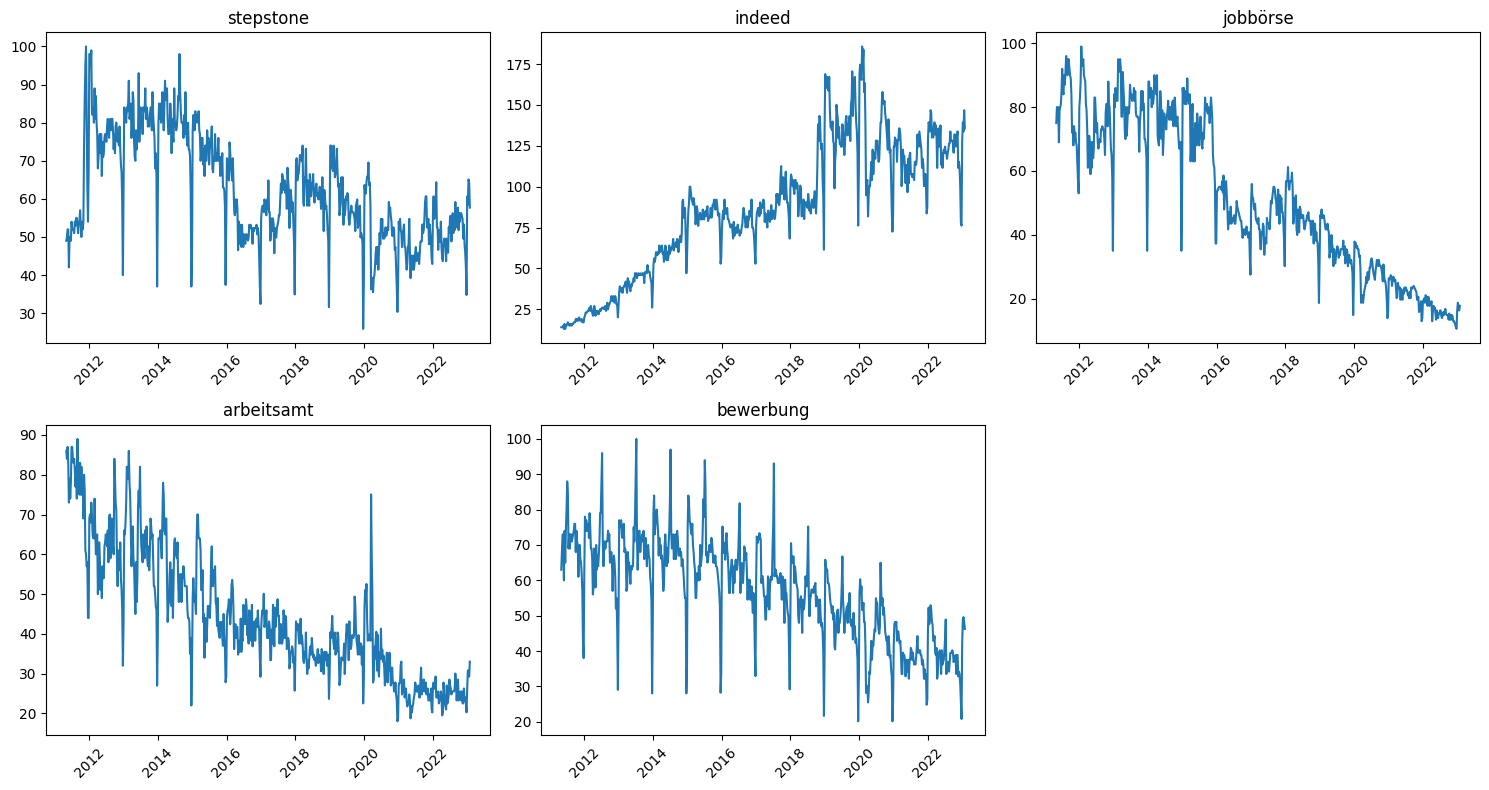

In [20]:
import matplotlib.pyplot as plt

keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    ax.plot(df_week["Date"], df_week[kw])
    ax.set_title(kw)
    ax.tick_params(axis='x', rotation=45)

# Remove unused subplot(s)
for ax in axes[len(keywords):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


## Descriptives of the biweekly data

The structure for the plotting section 
- (i) we plot the GT variables of W12 against W34 prev
- (ii) we plot each of the GT variables against unemplyoment rate
- (iii) we will take as well a look at possible cross correlations
- (iv) we plot seasonality boxplots 
- (v) we use an normalized index plot to compare google trends in the respective time frame

## (i) plotting the biweekly data against each other over time

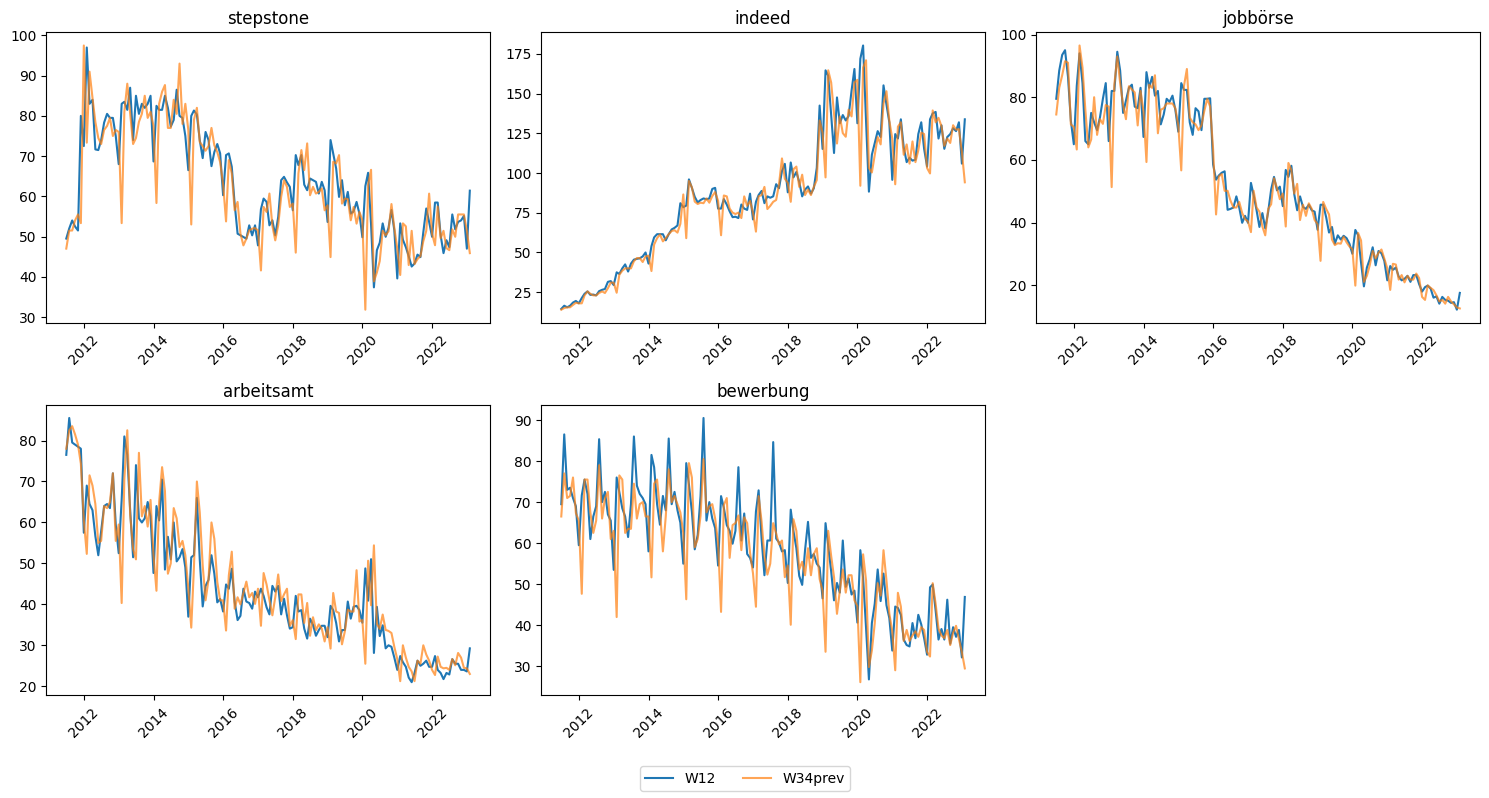

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Plot only as many subplots as you have keywords
for ax, kw in zip(axes, keywords):
    ax.plot(panel.index, panel[f"{kw}_W12"], label="W12")
    ax.plot(panel.index, panel[f"{kw}_W34prev"], label="W34prev", alpha=0.7)
    ax.set_title(kw)
    ax.tick_params(axis='x', rotation=45)

# Remove any unused axes (e.g. bottom-right panel)
for ax in axes[len(keywords):]:
    fig.delaxes(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


This figure compares, for each keyword, the two biweekly Google Trends aggregates used in the ARX timing specifications: the early-month window \(W12_t\) and the late-previous-month window \(W34_{t-1}\).

Several observations are noteworthy:

- For all keywords, the two series track each other very closely over time. Differences between \(W12_t\) and \(W34_{t-1}\) are small relative to their overall variation, indicating that search intensity evolves smoothly across the month boundary.
- No systematic lead–lag relationship is apparent from the plots. In particular, neither window consistently rises or falls ahead of the other, suggesting that the precise within-month timing of searches carries limited incremental information at the monthly horizon.
- Around major events such as the COVID-19 period, both windows exhibit pronounced movements, but these occur nearly simultaneously. This visual evidence foreshadows the later result that neither timing window reliably anticipates abrupt turning points in unemployment.
- The similarity between \(W12_t\) and \(W34_{t-1}\) holds across all keywords, including both job-platform-related terms and more generic search terms.
- Seasonality more pronounced especially in January in \(W12_t\) over \(W34_{t-1}\)

## (ii) Plotting the GT against unemployment iver time 
### first for W34 prev

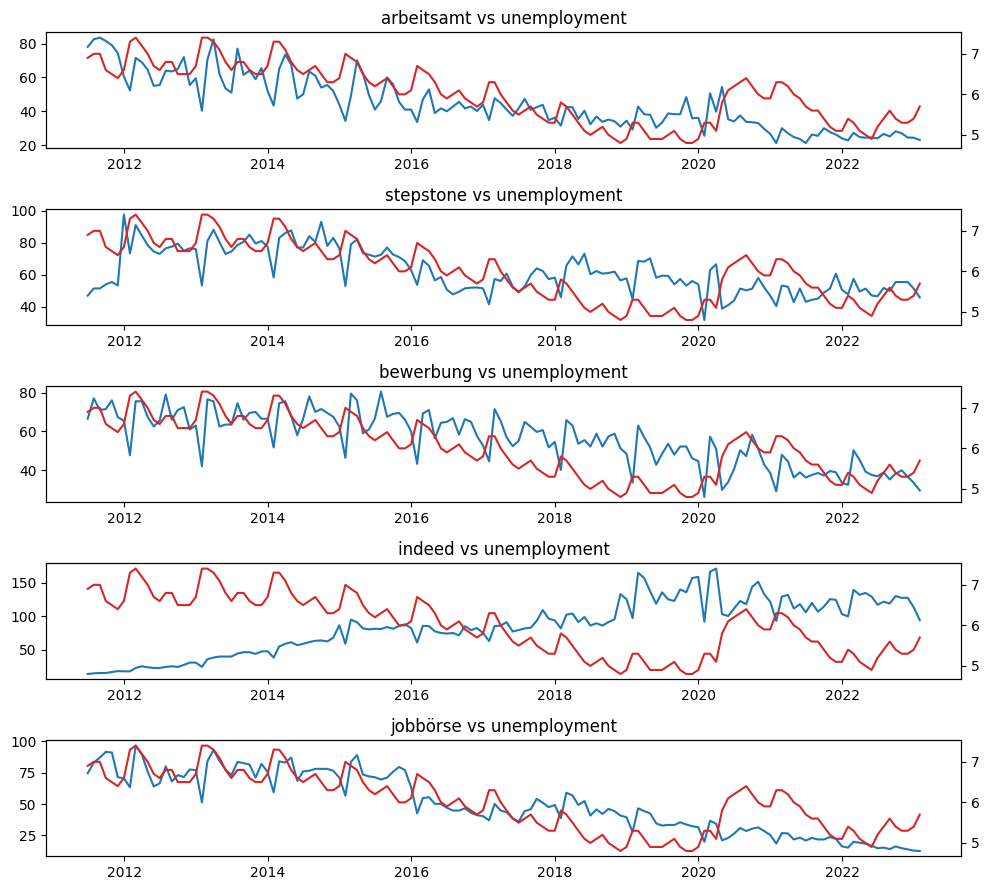

In [22]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9))

for ax, kw in zip(axes, ["arbeitsamt", "stepstone", "bewerbung","indeed","jobbörse"]):
    ax2 = ax.twinx()
    ax.plot(panel.index, panel[f"{kw}_W34prev"], label=f"{kw} (W34prev)", color="tab:blue")
    ax2.plot(panel.index, panel["Unemp"], label="Unemployment", color="tab:red")
    ax.set_title(f"{kw} vs unemployment")

plt.tight_layout()
plt.show()


### for W12

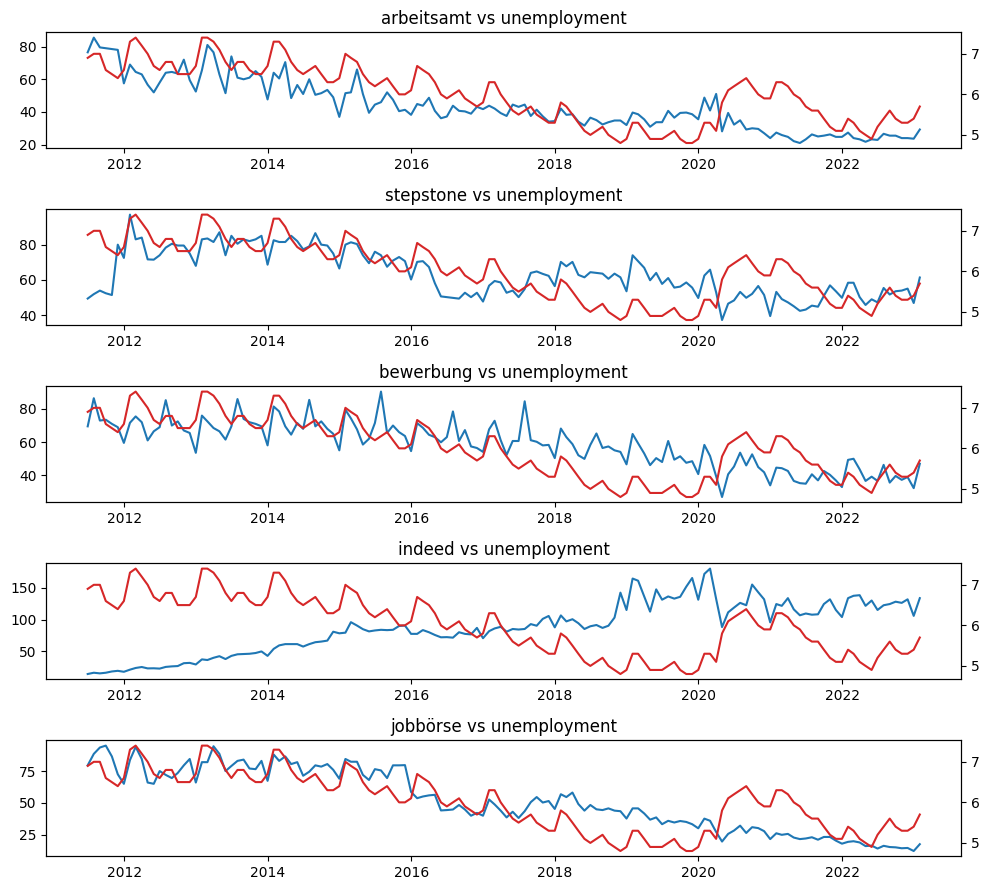

In [23]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9))

for ax, kw in zip(axes, ["arbeitsamt", "stepstone", "bewerbung","indeed","jobbörse"]):
    ax2 = ax.twinx()
    ax.plot(panel.index, panel[f"{kw}_W12"], label=f"{kw} (W12)", color="tab:blue")
    ax2.plot(panel.index, panel["Unemp"], label="Unemployment", color="tab:red")
    ax.set_title(f"{kw} vs unemployment")

plt.tight_layout()
plt.show()


## (iii) Cross correlation functions

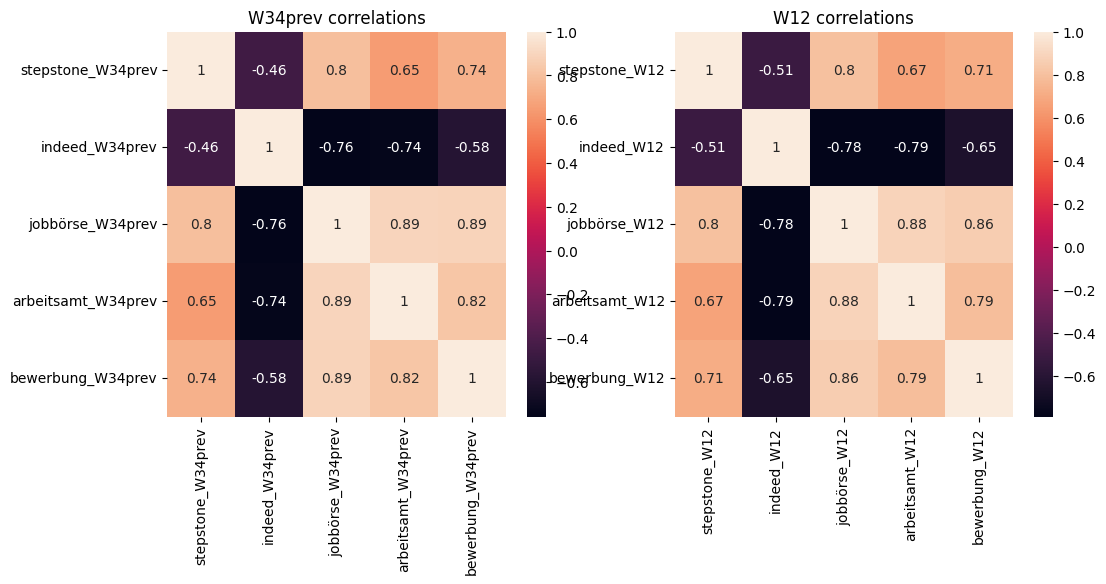

In [24]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(panel[[c for c in panel.columns if "W34prev" in c]].corr(), ax=axes[0], annot=True)
sns.heatmap(panel[[c for c in panel.columns if "W12" in c]].corr(), ax=axes[1], annot=True)
axes[0].set_title("W34prev correlations")
axes[1].set_title("W12 correlations")
plt.show()


This figure reports the pairwise correlation matrices for the biweekly Google Trends predictors, shown separately for the late-previous-month window \(W34_{t-1}\) and the early-month window \(W12_t\).

Two main patterns stand out:

- The correlation structure is very similar across the two timing windows. For each keyword pair, correlations in \(W12_t\) closely mirror those in \(W34_{t-1}\), reinforcing the earlier visual evidence that within-month timing differences do not materially alter the information content of the aggregated search data.
- Correlations are high and positive among most job-related search terms (*jobbörse*, *arbeitsamt*, *bewerbung*, *stepstone*), indicating that these keywords largely co-move and likely capture a common underlying factor related to job search intensity. By contrast, *indeed* exhibits systematically negative correlations with the other keywords, reflecting its distinct trend and volatility profile.



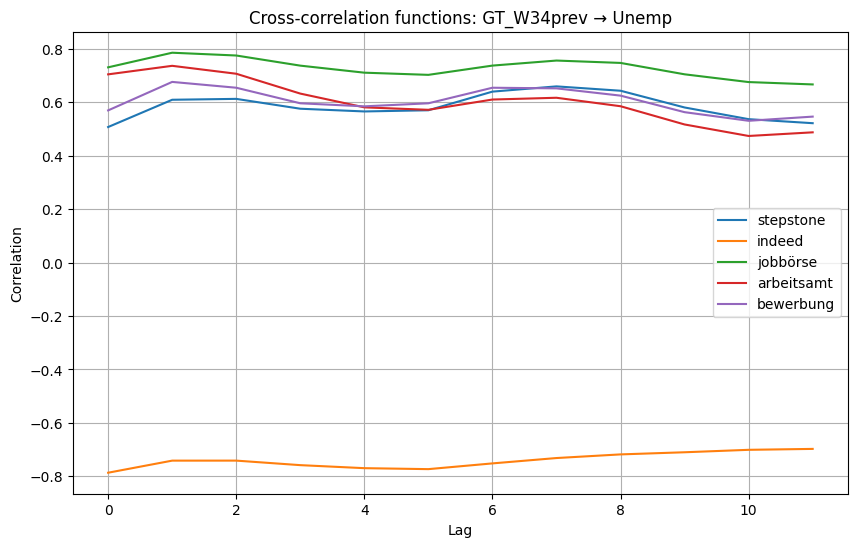

In [25]:
from statsmodels.tsa.stattools import ccf

lags = 12

plt.figure(figsize=(10, 6))

for kw in keywords:
    x = panel[f"{kw}_W34prev"]
    y = panel["Unemp"]
    corr = ccf(x, y)[:lags]
    plt.plot(range(lags), corr, label=f"{kw}")

plt.title("Cross-correlation functions: GT_W34prev → Unemp")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.show()

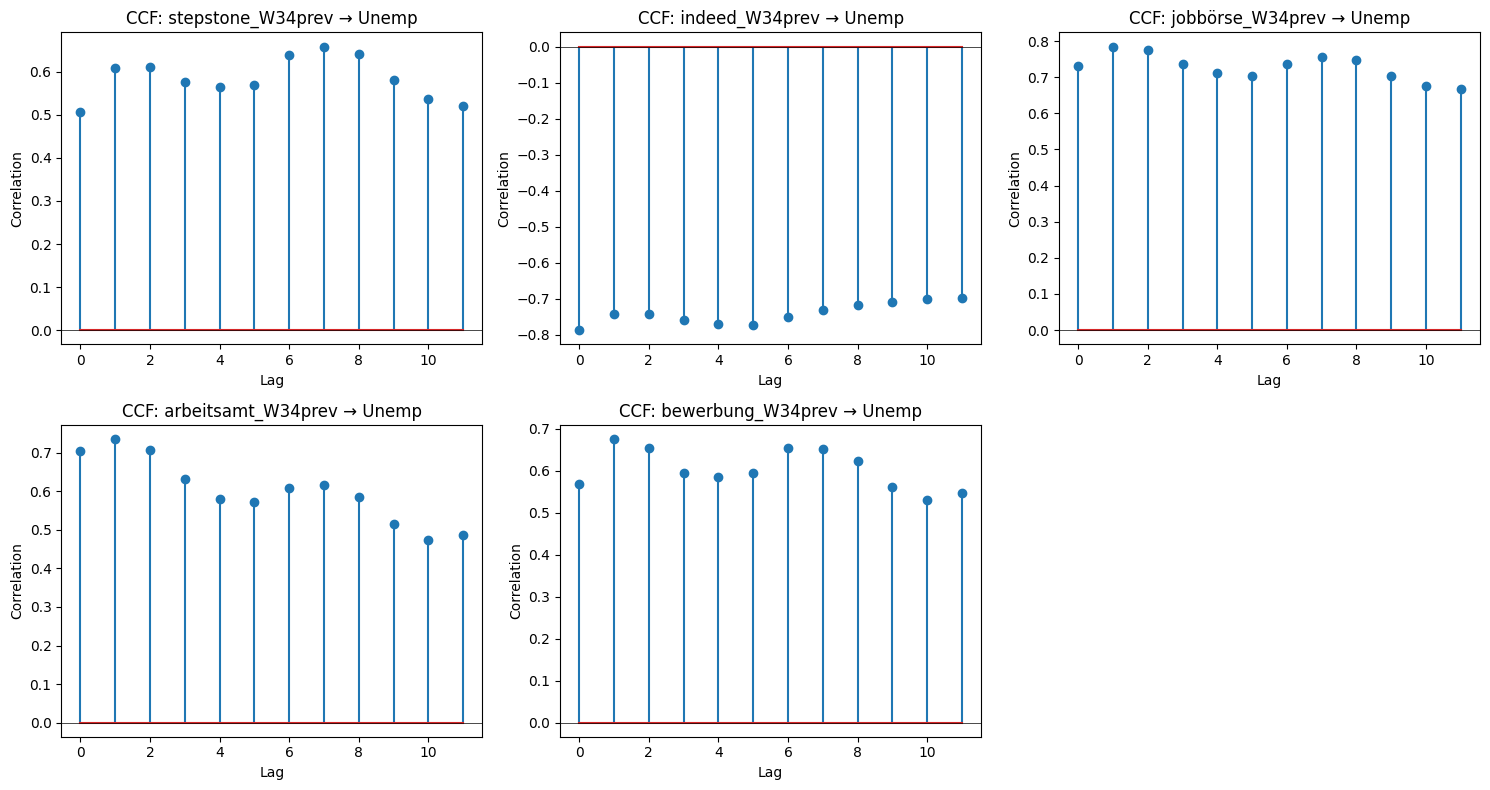

In [26]:
from statsmodels.tsa.stattools import ccf


lags = 12
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    x = panel[f"{kw}_W34prev"].astype(float).values
    y = panel["Unemp"].astype(float).values

    corr = ccf(x, y)[:lags]

    ax.stem(range(lags), corr)    # <-- FIXED
    ax.axhline(0, color="black", linewidth=0.5)

    ax.set_title(f"CCF: {kw}_W34prev → Unemp")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Correlation")

# Hide unused subplot
for ax in axes[len(keywords):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## (iv) Seasonality boxplots
### for W34 prev

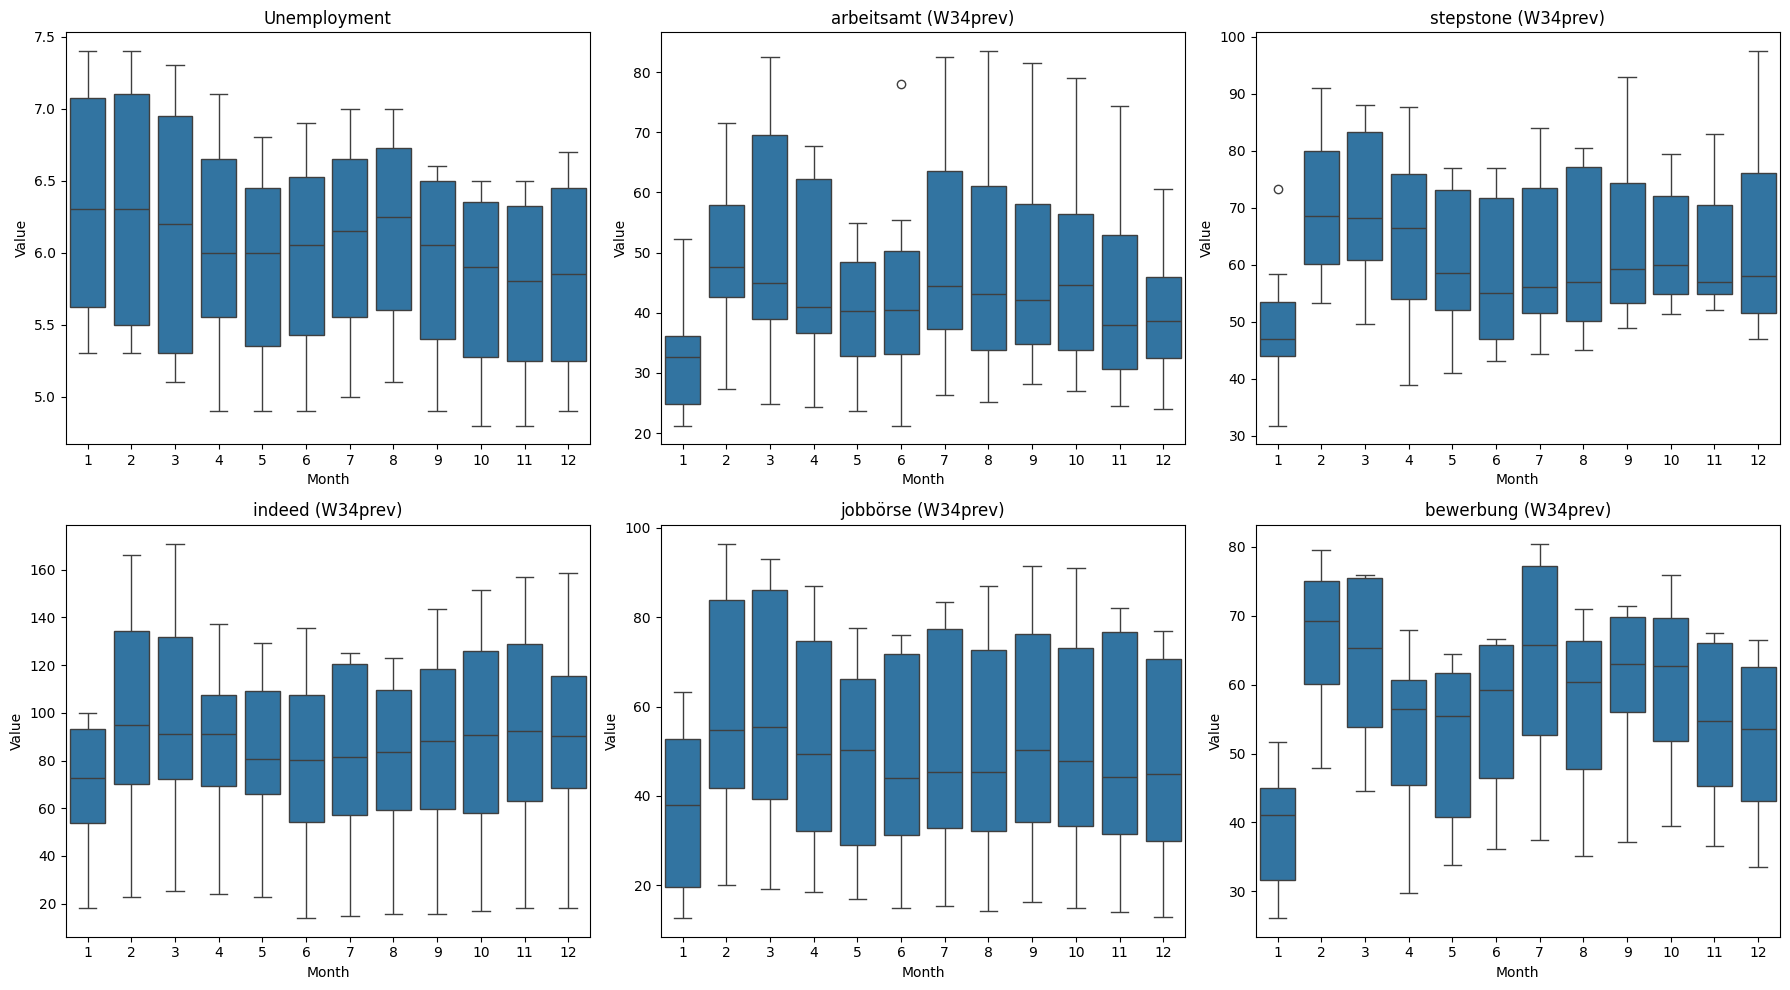

In [27]:
import seaborn as sns


# Ensure month column exists
panel["month"] = panel.index.month

# Order of variables shown in the grid
vars_to_plot = [
    "Unemp",
    "arbeitsamt_W34prev",
    "stepstone_W34prev",
    "indeed_W34prev",
    "jobbörse_W34prev",
    "bewerbung_W34prev"
]

titles = [
    "Unemployment",
    "arbeitsamt (W34prev)",
    "stepstone (W34prev)",
    "indeed (W34prev)",
    "jobbörse (W34prev)",
    "bewerbung (W34prev)"
]

# Create 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var, title in zip(axes, vars_to_plot, titles):
    sns.boxplot(x="month", y=var, data=panel, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


### for W12

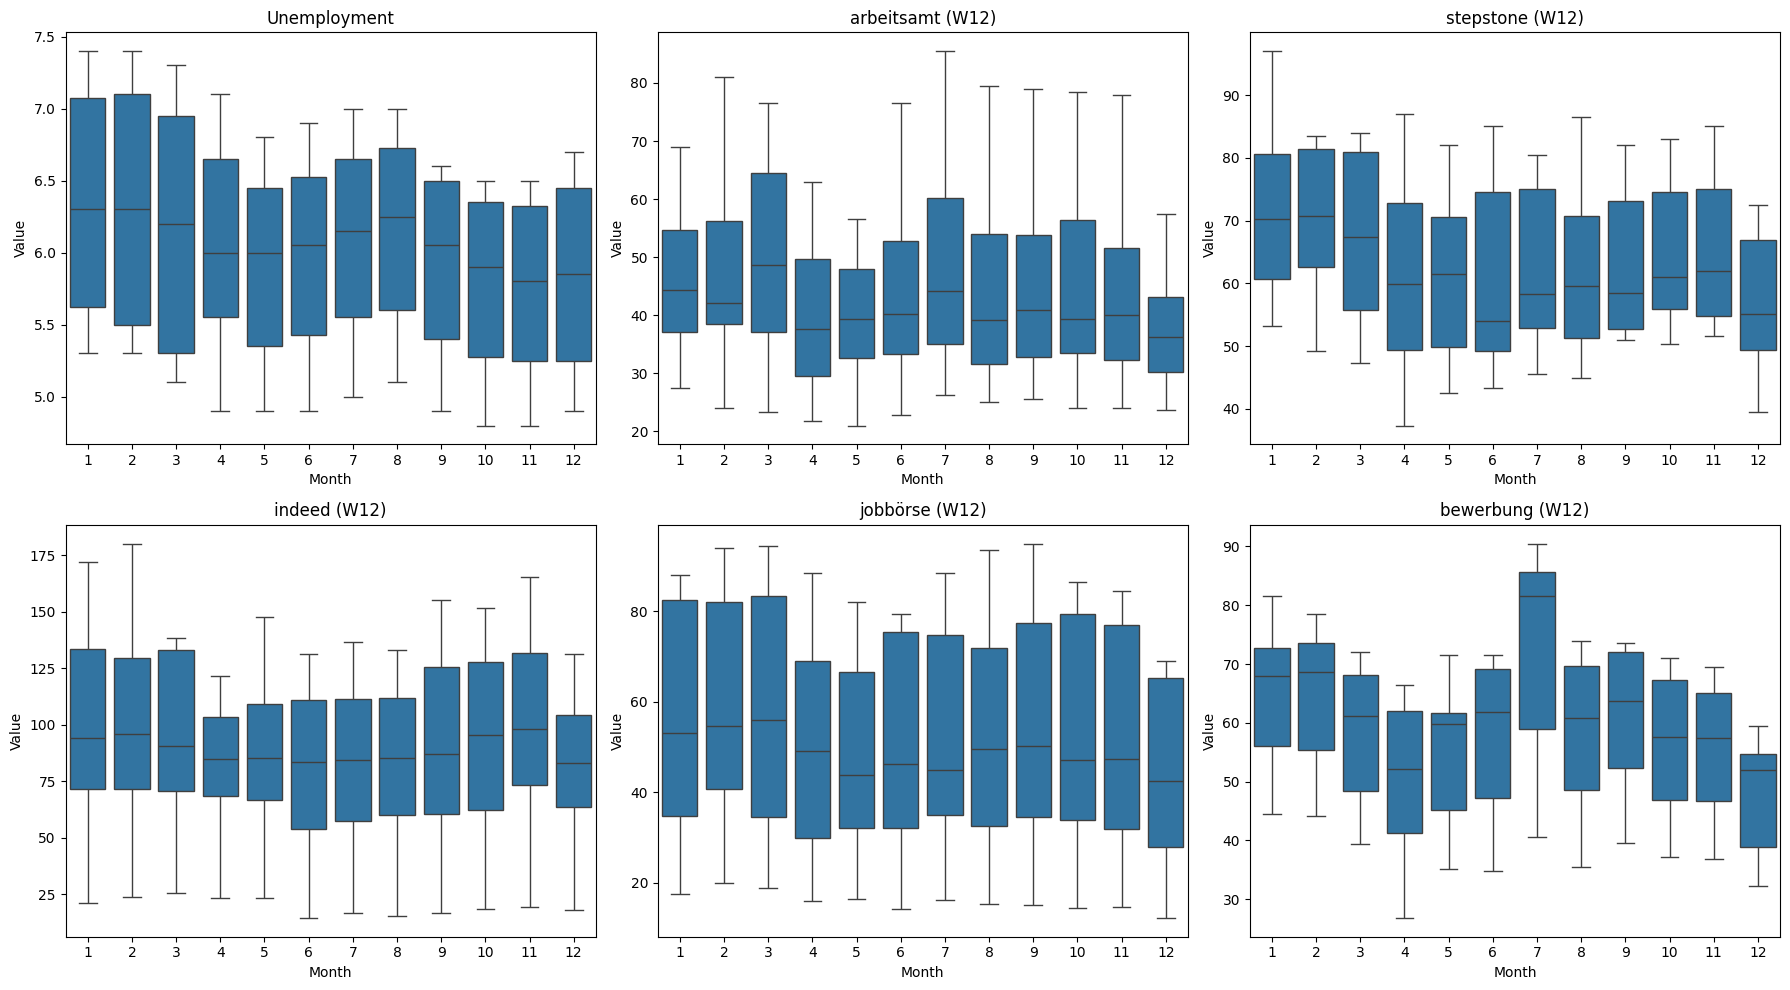

In [28]:


# Order of variables shown in the grid
vars_to_plot = [
    "Unemp",
    "arbeitsamt_W12",
    "stepstone_W12",
    "indeed_W12",
    "jobbörse_W12",
    "bewerbung_W12"
]

titles = [
    "Unemployment",
    "arbeitsamt (W12)",
    "stepstone (W12)",
    "indeed (W12)",
    "jobbörse (W12)",
    "bewerbung (W12)"
]

# Create 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var, title in zip(axes, vars_to_plot, titles):
    sns.boxplot(x="month", y=var, data=panel, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


## (v) Normalized index plot

### for W12

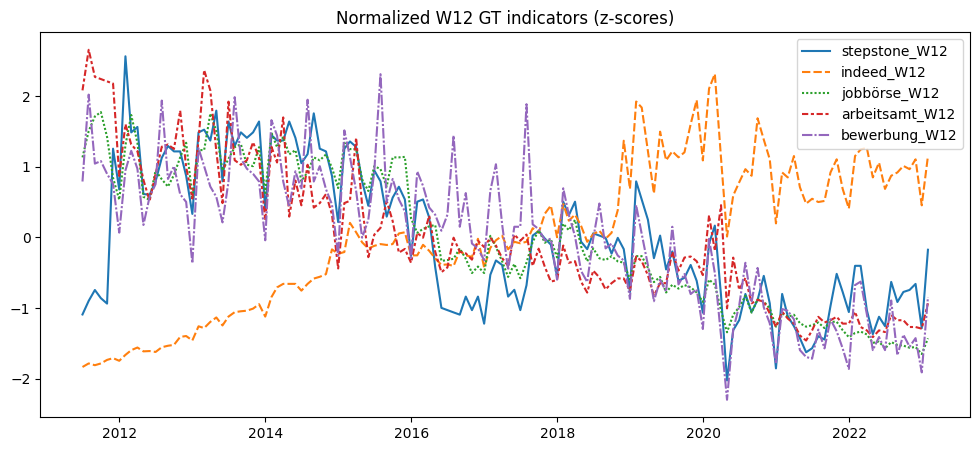

In [29]:

gt_cols = [col for col in panel.columns if "W12" in col]
gt_norm = (panel[gt_cols] - panel[gt_cols].mean()) / panel[gt_cols].std()

plt.figure(figsize=(12,5))
sns.lineplot(data=gt_norm)
plt.title("Normalized W12 GT indicators (z-scores)")
plt.show()


### for W34 prev

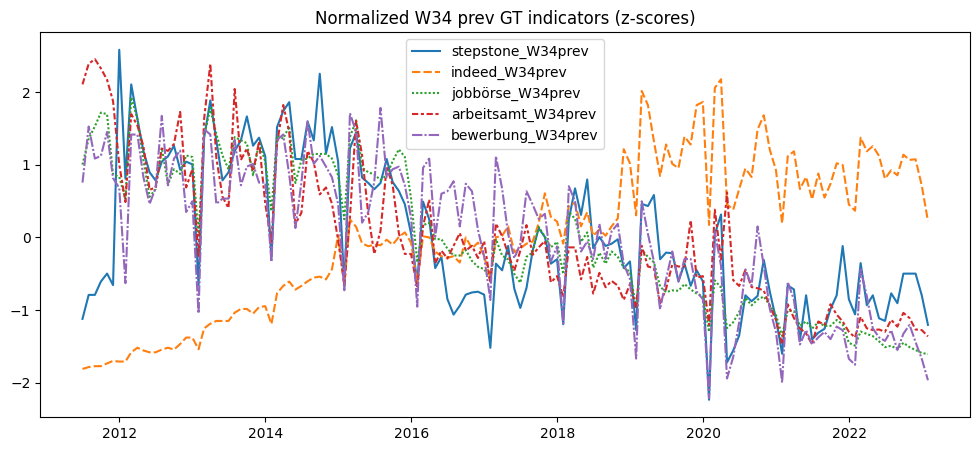

In [30]:

gt_cols = [col for col in panel.columns if "W34prev" in col]
gt_norm = (panel[gt_cols] - panel[gt_cols].mean()) / panel[gt_cols].std()

plt.figure(figsize=(12,5))
sns.lineplot(data=gt_norm)
plt.title("Normalized W34 prev GT indicators (z-scores)")
plt.show()

# Stationarity tests for the variables

###  Augmented Dickey–Fuller tests (levels vs. first differences)

This cell assesses the time-series properties of the monthly panel variables using Augmented Dickey–Fuller (ADF) tests. 

**Test design.**

For each series in the monthly panel (unemployment and all biweekly Google Trends predictors), the code runs ADF tests on:

- the **level** series, and
- the **first difference** (\(\Delta x_t\)).

For each transformation, three deterministic specifications are reported:

- `reg="n"`: no constant, no trend  
- `reg="c"`: constant only  
- `reg="ct"`: constant and linear time trend  

Lag length is selected by AIC (`autolag="AIC"`) subject to a maximum lag cap (`MAXLAG=13`). For each test, the output includes the ADF statistic, p-value, selected lag length, effective sample size, and rejection indicators at the 1%, 5%, and 10% levels.


The resulting summary is printed for transparency and written to `adf_panel_simple.csv`. The stationarity evidence informs the subsequent modeling choice to work with changes in unemployment and changes in search intensity in the pseudo real-time nowcasting exercise.


In [31]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller


MIN_LEN = 20
MAXLAG = 13           
OUT_CSV = "adf_panel_simple.csv"

def run_adf(series: pd.Series,
            name: str,
            maxlag: int = MAXLAG,
            min_len: int = MIN_LEN) -> pd.DataFrame:

    series = pd.to_numeric(series, errors="coerce")
    series = series.dropna()

    results = []
    cols = [
        "series", "transform", "reg",
        "adf_stat", "pvalue",
        "used_lag", "nobs_eff", "nobs_raw",
        "crit_1pct", "crit_5pct", "crit_10pct",
        "reject_1pct", "reject_5pct", "reject_10pct"
    ]

    def run_one(x, transform_label):
        x = pd.Series(x).dropna()
        nraw = x.shape[0]

        if nraw < min_len:
            for reg in ("n", "c", "ct"):
                results.append((name, transform_label, reg,
                                np.nan, np.nan,
                                np.nan, np.nan, nraw,
                                np.nan, np.nan, np.nan,
                                False, False, False))
            return

        for reg in ("n", "c", "ct"):
            stat, p, usedlag, nobs, crit, icbest = adfuller(
                x,
                regression=reg,          
                maxlag=maxlag,
                autolag="AIC"             # lag chosen by AIC
            )
            c1, c5, c10 = crit["1%"], crit["5%"], crit["10%"]

            # reject if statistic is more negative than critical value
            r1 = stat < c1
            r5 = stat < c5
            r10 = stat < c10

            results.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))

    # Level
    run_one(series, "level")
    # First difference
    run_one(series.diff(), "diff1")

    return pd.DataFrame(results, columns=cols)




all_res = []

for col in panel.columns:
    res = run_adf(panel[col], name=col)
    all_res.append(res)

    print("\n" + "="*70)
    print(f"ADF results for {col}")
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res.to_string(index=False))

adf_summary = pd.concat(all_res, ignore_index=True)
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved ADF summary to {OUT_CSV}")



ADF results for stepstone_W12
       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W12     level   n   -0.9831  0.2949        12       127       140    -2.5836    -1.9433     -1.6149        False        False         False
stepstone_W12     level   c   -1.6889  0.4368        13       126       140    -3.4833    -2.8848     -2.5792        False        False         False
stepstone_W12     level  ct   -2.5111  0.3224        13       126       140    -4.0325    -3.4459     -3.1478        False        False         False
stepstone_W12     diff1   n   -3.2242  0.0013        11       127       139    -2.5836    -1.9433     -1.6149         True         True          True
stepstone_W12     diff1   c   -3.2986  0.0149        11       127       139    -3.4829    -2.8846     -2.5791        False         True          True
stepstone_W12     diff1  ct   -3.2441  0.0760        11       127    

### Stationarity diagnostics for weekly Google Trends series

This step applies the same Augmented Dickey–Fuller testing framework to the **weekly Google Trends series**.

Two adjustments relative to the monthly-panel ADF tests are important:

- The `Date` index is removed before testing. The ADF test is applied to the raw weekly series themselves; the calendar index does not enter the test and would otherwise be treated as a deterministic component.


As in the monthly case, ADF tests are run on both levels and first differences, and under alternative deterministic specifications (no constant, constant, constant plus trend). The results are printed for each keyword.

These diagnostics typically indicate strong persistence and non-stationarity in the weekly Google Trends series in levels, with stationarity achieved only after differencing. 


In [32]:
# removing the week index for the dickey fuller test as it is a constant 
week_stat = df_week.copy()
week_stat.drop(columns="Date", axis = 1, inplace=True)
# defining the upper bound for the weekly data
MIN_LEN = 20
MAXLAG = 52          

all_res = []

for col in week_stat.columns:
    res = run_adf(week_stat[col], name=col)
    all_res.append(res)

    print("\n" + "="*70)
    print(f"ADF results for {col}")
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res.to_string(index=False))

adf_summary = pd.concat(all_res, ignore_index=True)



ADF results for stepstone
   series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone     level   n   -0.3352  0.5624        13       600       614    -2.5695    -1.9415     -1.6164        False        False         False
stepstone     level   c   -2.3279  0.1631        12       601       614    -3.4413    -2.8664     -2.5693        False        False         False
stepstone     level  ct   -4.9716  0.0002         8       605       614    -3.9738    -3.4178     -3.1313         True         True          True
stepstone     diff1   n  -10.1611  0.0000        12       600       613    -2.5695    -1.9415     -1.6164         True         True          True
stepstone     diff1   c  -10.1526  0.0000        12       600       613    -3.4413    -2.8664     -2.5693         True         True          True
stepstone     diff1  ct  -10.1639  0.0000        12       600       613    -3.9739    -3.4178    

### Constructing the weekly Google Trends panel used as high-frequency input

This cell prepares the weekly Google Trends dataset in a form that can be used consistently throughout the nowcasting exercise.

- First, it asserts that the raw weekly dataframe `df_week` still contains a `Date` column. This is a guardrail to ensure earlier data-processing steps have not dropped or renamed the time index.
- It then creates a defensive copy of `df_week` to avoid mutating the object in place.
- The `Date` column is converted to a proper `datetime` type and any timezone information is removed to avoid downstream alignment issues when merging with monthly series.
- Finally, the weekly series are restricted to the five keyword columns used in the study and stored in `weekly_panel` as a time-indexed dataframe (weekly frequency, `Date` as index).

The resulting object `weekly_panel` is the canonical weekly input panel for the MIDAS / U-MIDAS nowcasting framework.


In [33]:
# Read in the packages
import statsmodels.api as sm
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit



In [34]:
# --- mandatory weekly_panel fix ---
assert "Date" in df_week.columns, "df_week must still contain a Date column at this step."

df_week = df_week.copy()
df_week["Date"] = pd.to_datetime(df_week["Date"], errors="coerce").dt.tz_localize(None)
df_week = df_week.sort_values("Date")

weekly_cols = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
weekly_panel = df_week.set_index("Date")[weekly_cols].sort_index()

# sanity checks
print(weekly_panel.index.min(), weekly_panel.index.max())
print(weekly_panel.index[:5])


2011-05-01 00:00:00 2023-01-29 00:00:00
DatetimeIndex(['2011-05-01', '2011-05-08', '2011-05-15', '2011-05-22',
               '2011-05-29'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [35]:
weekly_panel

,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
Date,,,,,
2011-05-01,49.000000,14.000000,75.000000,86.000000,63.000000
2011-05-08,50.000000,14.000000,80.000000,84.000000,68.000000
2011-05-15,52.000000,14.000000,80.000000,87.000000,73.000000
2011-05-22,52.000000,15.000000,80.000000,83.000000,73.000000
2011-05-29,42.000000,13.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...
2023-01-01,60.670120,128.215336,16.313392,26.270023,42.207649
2023-01-08,58.450482,139.364496,18.712420,30.773455,48.907276
2023-01-15,65.109398,133.789916,17.752809,30.773455,49.577239


In [36]:
panel

,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp,month
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000,6.9,6
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000,7.0,7
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,51.500000,15.500000,87.000000,83.500000,71.000000,7.0,8
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000,6.6,9
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000,6.5,10
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873,5.4,9
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780,5.3,10
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627,5.3,11
2022-12-31,46.982349,105.917017,12.235044,23.643021,32.158209,51.421627,113.349790,12.954753,24.393593,33.498134,5.4,12


### Output check: date coverage and weekly index structure

The printed output reports the earliest and latest weekly observations and shows the first few index values.

- Coverage runs from **2011-05-01** to **2023-01-29**, confirming a long weekly history.
- The first index entries increase in 7-day steps, indicating the dataset is stored as a regular weekly time index (even though pandas may not assign a fixed `freq` attribute).

This is a quick sanity check that the weekly panel is sorted correctly and that the time index is usable for rolling aggregations and month-alignment later in the pipeline.




### Visual inspection before the nowcasting framework

Before defining the nowcasting functions, you inspect the two core datasets that will be used throughout the forecasting pipeline:

1. **`weekly_panel` (weekly frequency, 614 rows × 5 columns)**  
   This is the cleaned weekly Google Trends panel for the five keywords:
   `stepstone`, `indeed`, `jobbörse`, `arbeitsamt`, `bewerbung`.  
   These series are the high-frequency predictors that later enter the MIDAS / U-MIDAS specifications.

2. **Monthly modeling panel (140 rows × 12 columns)**  
   This is the monthly dataset used for estimation and evaluation. It contains:
   - Two alternative monthly aggregations of weekly search intensity for each keyword  
     `*_W12` (weeks 1–2 of the month) and `*_W34prev` (weeks 3–4 of the previous month),
   - The monthly unemployment series `Unemp`,
   - The calendar control `month`.

Inspecting both objects at this point serves a specific purpose: it confirms that the weekly raw inputs and the derived monthly predictors are coherent before the code moves into the nowcasting framework, where these panels will be repeatedly merged, lagged, and passed through forecast routines.


# Nowcasting framework: central configuration object (`CFG`)

This cell defines a single configuration container that controls all key choices in the nowcasting pipeline. The goal is reproducibility and consistency: instead of scattering parameters across many functions, the notebook stores them in one `CFG` object and passes that object (or reads from it) wherever needed.

Using a `@dataclass` makes the configuration explicit, typed, and easy to modify. It also reduces the risk of silently changing parameters between model runs.


In [37]:
from dataclasses import dataclass
from typing import Tuple

@dataclass
class CFG:
    # Sample endpoints
    start_week: str = "2011-05-01"
    end_week: str   = "2023-01-29"
    start_month: str = "2011-06-30"
    end_month: str   = "2023-01-31"

    # Evaluation timeframe
    eval_start: str = "2019-01-31"
    min_train: int = 60

    # Deterministics / transformations
    seasonal_dummies: bool = True
    target_transform: str = "diff"   # keep diff for nowcasting baseline

    # Lag selection controls
    ar_max_p: int = 6
    arx_max_p: int = 4
    arx_max_q: int = 2
    ic: str = "BIC"                  # AIC or BIC

    # MIDAS controls
    midas_K_candidates: Tuple[int, ...] = (4, 6, 8)
    midas_include_ar: bool = True
    midas_diff_weekly: bool = True

    # MIDAS robustness
    midas_K_robustness: Tuple[int, ...] = (4, 6, 8, 10)

cfg = CFG()


### `CFG`: deterministic controls and target transformation

This block sets modeling choices that apply across specifications.

- `seasonal_dummies=True` means monthly seasonal controls are included where applicable (typically via month-of-year dummies).
- `target_transform="diff"` indicates that the target variable is modeled in first differences (e.g., $\Delta U_t$). This is aligned with the baseline nowcasting setup in the thesis and is applied consistently across models.

### `CFG`: MIDAS / U-MIDAS specification controls

- `midas_include_ar=True` means the preferred MIDAS specifications are augmented with an autoregressive term in the monthly target, matching the "U-MIDAS(with AR)" models discussed in the paper.
- `midas_diff_weekly=True` indicates that weekly Google Trends predictors are differenced before entering the MIDAS regression. This mirrors the transformation used elsewhere to work with changes rather than levels and to reduce low-frequency non-stationarity in the weekly signals.
- `midas_K_robustness` extends the MIDAS lag-length grid to include $K=10$ in addition to the baseline values.





# 3.1 Building the U-MIDAS design matrix (weekly predictors aligned to monthly targets)

This function constructs the regression dataset used by the U-MIDAS models. It aligns a monthly unemployment target with the most recent \(K\) weekly observations of a selected Google Trends keyword and optionally adds monthly seasonal dummies.

The output is a time-indexed design matrix where each row corresponds to one month in the estimation/evaluation sample.


Key inputs are:

- `weekly_panel`: weekly Google Trends panel (date index).
- `unemp_monthly`: monthly unemployment series (monthly index).
- `gt_col`: which keyword series to use as the weekly predictor.
- `K`: number of weekly lags included per month .
- `target_transform` and `weekly_transform`: whether the monthly target and weekly predictor enter in levels or first differences.



In [38]:
from typing import Optional

def build_umidas_design(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    K: int = 8,
    target_transform: str = "diff",   # "diff" or "level"
    weekly_transform: str = "diff",   # "diff" or "level"
    seasonal_dummies: bool = True,
    drop_first_dummy: bool = True,
    cutoff_dates: Optional[pd.Series] = None,   
    cutoff_inclusive: bool = True              
) -> pd.DataFrame:

    # --- Ensure proper indices
    wk = weekly_panel[[gt_col]].copy().sort_index()
    wk.index = pd.to_datetime(wk.index).tz_localize(None)

    U = unemp_monthly.copy().sort_index()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    # --- Transform target and weekly regressor
    y = U.diff() if target_transform == "diff" else U
    x = wk[gt_col].diff() if weekly_transform == "diff" else wk[gt_col]

    # --- Build rows
    rows = []
    idx = []
    for t in y.index:
        if pd.isna(y.loc[t]):
            continue

        # <<< NEW: month-specific cutoff (e.g., Stichtag) instead of month-end t
        if cutoff_dates is not None and t in cutoff_dates.index and pd.notna(cutoff_dates.loc[t]):
            c_t = pd.to_datetime(cutoff_dates.loc[t]).tz_localize(None)
        else:
            c_t = t  # fallback to month-end if no cutoff provided

        c_t_minus = c_t - pd.Timedelta(seconds=1)

        x_up_to_t = x.loc[x.index <= c_t_minus].dropna()

        if len(x_up_to_t) < K:
            continue

        lastK = x_up_to_t.iloc[-K:]  # oldest..newest
        # define wlag0 = most recent week, wlag1 = one week older, ...
        vals = lastK.iloc[::-1].values

        rows.append([y.loc[t]] + list(vals))
        idx.append(t)

    cols = ["y"] + [f"wlag{k}" for k in range(K)]
    design = pd.DataFrame(rows, index=pd.to_datetime(idx), columns=cols).sort_index()

    # --- Optional seasonal dummies on monthly index
    if seasonal_dummies:
        d = pd.get_dummies(design.index.month, prefix="m", drop_first=drop_first_dummy).astype(float)
        d.index = design.index
        design = pd.concat([design, d], axis=1)

    return design



## 3.2 Evaluation settings used in the out-of-sample nowcasting loop

These two constants pull the evaluation start date and the minimum training sample size from the central configuration object cfg.

- `EVAL_START` defines when the out-of-sample evaluation begins.
- `MIN_TRAIN` ensures that the expanding-window estimation does not start until a sufficient number of monthly observations is available.

`compute_metrics(pred, act)` returns

- RMSE (root mean squared error),
- MAE (mean absolute error),
- `n` (the number of evaluated out-of-sample observations).

This function is used to summarize and compare model performance consistently across all specifications.

`month_dummies(index, drop_first=True)` creates month-of-year dummy variables from a monthly datetime index.

These deterministic controls are used in models where seasonal effects are included, and drop_first=True avoids perfect multicollinearity by omitting one reference month.


In [39]:
EVAL_START = cfg.eval_start
MIN_TRAIN  = cfg.min_train

def compute_metrics(pred: pd.Series, act: pd.Series) -> dict:
    pred, act = pred.align(act, join="inner")
    err = pred - act
    return {
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "n": int(err.shape[0]),
    }

def month_dummies(index: pd.DatetimeIndex, drop_first=True) -> pd.DataFrame:
    d = pd.get_dummies(index.month, prefix="m", drop_first=drop_first).astype(float)
    d.index = index
    return d


# 3.3 Helper function: partialling out deterministic controls (Frisch–Waugh–Lovell step)

`partial_out_dummies(D, y, X)` residualizes the target y and the regressors X`with respect to a set of deterministic controls D (typically seasonal month dummies), including an intercept.



The function outputs:
- `y_tilde`: the residualized target series 
- `X_tilde`: the residualized regressor matrix 
- `gamma_hat`: coefficients from the auxiliary regression 
- `A_hat`: coefficients from the auxiliary regression `X ~ D` 
- `Dm.columns`: the names of the control variables used (including the inserted intercept).







In [40]:
def partial_out_dummies(
    D: pd.DataFrame,
    y: pd.Series,
    X: pd.DataFrame
):

    Dm = D.copy()
    Dm.insert(0, "const", 1.0)


    Dv = Dm.values
    yv = y.values.reshape(-1, 1)
    Xv = X.values

 
    gamma_hat, *_ = np.linalg.lstsq(Dv, yv, rcond=None) 
    y_hat = Dv @ gamma_hat
    y_tilde = (yv - y_hat).ravel()

    A_hat, *_ = np.linalg.lstsq(Dv, Xv, rcond=None)     
    X_hat = Dv @ A_hat
    X_tilde = Xv - X_hat

    y_tilde = pd.Series(y_tilde, index=y.index, name=y.name)
    X_tilde = pd.DataFrame(X_tilde, index=X.index, columns=X.columns)

    return y_tilde, X_tilde, gamma_hat, A_hat, Dm.columns


## 3.4 Model selection utilities for AR and ARX specifications

This block defines helper functions that select lag lengths for the benchmark AR model and the ARX models using an information criterion. 

`select_arx_pq(y, x, max_p, max_q, ic, dummies)` performs a grid search over:
- autoregressive lags \(p = 1, \dots, \texttt{max\_p}\), and
- distributed lags of the exogenous regressor \(q = 0, \dots, \texttt{max\_q}\).

For each candidate pair \((p,q)\), it estimates:
- lags of the target \(y_{t-1}, \dots, y_{t-p}\), and
- current and lagged values of the predictor \(x_t, x_{t-1}, \dots, x_{t-q}\),

again with optional seasonal dummies. The function returns the \((p,q)\) combination that minimizes the selected information criterion.






In [41]:
from typing import Optional, Tuple

def ic_value(res, ic: str) -> float:
    ic = ic.upper()
    if ic == "AIC":
        return float(res.aic)
    elif ic == "BIC":
        return float(res.bic)
    else:
        raise ValueError("ic must be 'AIC' or 'BIC'")

def select_ar_p(y: pd.Series, max_p: int, ic: str, dummies: Optional[pd.DataFrame]) -> int:
    best = (np.inf, 1)
    for p in range(1, max_p + 1):
        df = pd.concat([y] + [y.shift(j) for j in range(1, p + 1)], axis=1)
        df.columns = ["y"] + [f"lag{j}" for j in range(1, p + 1)]
        if dummies is not None:
            df = df.join(dummies)
        df = df.dropna()
        if df.empty:
            continue
        res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
        val = ic_value(res, ic)
        if val < best[0]:
            best = (val, p)
    return best[1]

def select_arx_pq(y: pd.Series, x: pd.Series, max_p: int, max_q: int, ic: str, dummies: Optional[pd.DataFrame]) -> Tuple[int, int]:
    best = (np.inf, 1, 0)
    base = pd.concat([y.rename("y"), x.rename("x")], axis=1)

    for p in range(1, max_p + 1):
        for q in range(0, max_q + 1):
            df = base.copy()
            for j in range(1, p + 1):
                df[f"y_lag{j}"] = df["y"].shift(j)
            for k in range(0, q + 1):
                df[f"x_lag{k}"] = df["x"].shift(k)
            if dummies is not None:
                df = df.join(dummies)
            df = df.dropna()
            if df.empty:
                continue
            res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
            val = ic_value(res, ic)
            if val < best[0]:
                best = (val, p, q)
    return best[1], best[2]



## 3.5 Hyperparameter selection for penalized regressions using time-series cross-validation

`select_alpha_tscv` selects the regularization strength  for ridge or lasso regression using a time-series cross-validation scheme. This is used when estimating models with many weekly lag regressors, where shrinkage helps control overfitting.

The procedure uses TimeSeriesSplit, which implements expanding-window folds that respect the time ordering of the data. For each candidate alpha, the model is repeatedly trained on an earlier subsample and evaluated on the subsequent hold-out block.

For each fold, the function computes the mean squared error (MSE) of the forecasts on the test block, averages the MSEs across folds, and selects the alpha that minimizes the average MSE.


In [42]:
def select_alpha_tscv(
    X: pd.DataFrame,
    y: pd.Series,
    model: str,
    alphas,
    n_splits: int = 5
) -> float:

    Xv = X.values
    yv = y.values


    if len(yv) < (n_splits + 1):
        n_splits = max(2, min(n_splits, len(yv) - 1))

    tscv = TimeSeriesSplit(n_splits=n_splits)

    best_alpha, best_mse = None, np.inf

    for a in alphas:
        if model == "ridge":
            est = Pipeline([
                ("scaler", StandardScaler()),
                ("mdl", Ridge(alpha=a, fit_intercept=False))
            ])
        elif model == "lasso":
            est = Pipeline([
                ("scaler", StandardScaler()),
                ("mdl", Lasso(alpha=a, max_iter=20000, fit_intercept=False))
            ])
        else:
            raise ValueError("model must be 'ridge' or 'lasso'")

        mses = []
        for train_idx, test_idx in tscv.split(Xv):
            est.fit(Xv[train_idx], yv[train_idx])
            yhat = est.predict(Xv[test_idx])
            mses.append(float(np.mean((yv[test_idx] - yhat) ** 2)))

        mse = float(np.mean(mses))
        if mse < best_mse:
            best_mse, best_alpha = mse, a

    return float(best_alpha)


In [43]:
# the results container
@dataclass
class Result:
    name: str
    pred: pd.Series
    act: pd.Series
    err: pd.Series
    metrics: Dict[str, float]
    meta: Dict[str, object]


# 4.Nowcasting models

## 4.1 Nowcasting functions for the AR and ARX benchmarks (expanding-window, one-step-ahead)

The two functions below implement the baseline nowcasting models used as benchmarks in the empirical analysis. Both operate on the monthly panel and generate **one-step-ahead nowcasts** in an **expanding-window** setting. For each evaluation month \(t\), the model is re-estimated using only data strictly prior to \(t\), and the fitted coefficients are then used to produce the nowcast for month \(t\). A minimum training size (`min_train`) ensures that estimation only starts once a sufficiently long history is available.

Both models are estimated on the **first difference of unemployment**, \(\Delta U_t\), to match the transformation used in the main forecasting framework. After predicting \(\Delta U_t\), the code maps the prediction back into unemployment levels by adding the forecasted change to the last observed level \(U_{t-1}\). Optional **month-of-year dummy variables** can be included to control for seasonal patterns in unemployment.

- `nowcast_ar_diff` estimates an autoregressive benchmark where \(\Delta U_t\) depends only on its own lags.
- `nowcast_arx_diff` extends this benchmark by adding differenced Google Trends predictors (and their lags), allowing the exogenous series to contribute additional information beyond the autoregressive dynamics.

The outputs are aligned monthly time series of predicted unemployment levels and realized unemployment, which are then used to compute out-of-sample accuracy metrics and to compare performance across models.


In [44]:
def nowcast_ar_diff(panel: pd.DataFrame, start_eval: str,
                    p: int = 2, min_train: int = 60,
                    seasonal_dummies: bool = True):
    df = panel[["Unemp"]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    dU = U.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)]
    

    preds, acts, idx = [], [], []
    phi_path = []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()
        phi_path.append((t, res.params["dU_lag1"]))

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]     
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name="AR_pred")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act, phi_path


def nowcast_arx_diff(panel: pd.DataFrame, xcol: str, start_eval: str,
                     p: int = 2, q: int = 0,
                     min_train: int = 60,
                     seasonal_dummies: bool = True):

    df = panel[["Unemp", xcol]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    Xraw = pd.to_numeric(df[xcol], errors="coerce")

    dU = U.diff()
    dX = Xraw.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    df["dX_lag0"] = dX
    for k in range(1, q + 1):
        df[f"dX_lag{k}"] = dX.shift(k)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)] + ["dX_lag0"] + [f"dX_lag{k}" for k in range(1, q + 1)]

    preds, acts, idx = [], [], []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"ARX_pred_{xcol}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act




## 4.2 Nowcasting functions for U-MIDAS specifications (unpenalized and penalized variants)

The functions below implement the U-MIDAS nowcasting models that use weekly Google Trends information to predict monthly unemployment in real time. The workflow is consistent with the benchmark functions: forecasts are generated in an expanding-window setting, and for each evaluation month \(t\) the model is estimated using only data prior to \(t\), then used to produce a one-step-ahead nowcast for month \(t\).

`nowcast_umidas` is the baseline U-MIDAS implementation. It first builds a monthly design matrix that contains the target  and the most recent \(K\) weekly observations of a chosen keyword series. The specification can optionally include an autoregressive term in the monthly target and seasonal month dummies. The model is then estimated by OLS each month in the evaluation window, and predicted values are converted back to unemployment levels when the target is modeled in differences.

`nowcast_umidas_penalized_partialout` implements a penalized U-MIDAS variant using ridge or lasso. This is designed for settings where the weekly lag vector is large and overfitting is a concern. The key design choice is that seasonal dummies are treated as deterministic controls and are effectively left unpenalized by partialling them out before fitting the penalized regression. Regularization is applied only to the substantive predictors, namely the weekly lag regressors and (if included) the AR term. The penalty strength is selected using time-series cross-validation on the residualized data. Predictions are then reconstructed by combining the penalized component with the seasonal component and, if required, mapped back to unemployment levels.


In [45]:
def nowcast_umidas(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    start_eval: str,
    K: int = 8,
    include_ar1: bool = True,
    target_transform: str = "diff",
    weekly_transform: str = "diff",
    seasonal_dummies: bool = True,
    min_train: int = 60,
    cutoff_dates: Optional[pd.Series] = None,
    cutoff_inclusive: bool = True 
):
    design = build_umidas_design(
        weekly_panel=weekly_panel,
        unemp_monthly=unemp_monthly,
        gt_col=gt_col,
        K=K,
        target_transform=target_transform,
        weekly_transform=weekly_transform,
        seasonal_dummies=seasonal_dummies,
        cutoff_dates=cutoff_dates,
        cutoff_inclusive=cutoff_inclusive
    )


    if include_ar1:
        design["y_lag1"] = design["y"].shift(1)

    reg_cols = [c for c in design.columns if c.startswith("wlag")]
    if include_ar1:
        reg_cols += ["y_lag1"]
    reg_cols += [c for c in design.columns if c.startswith("m_")]


    U = unemp_monthly.copy()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    preds, acts, idx = [], [], []

    for t in design.loc[start_eval:].index:
        est = design.loc[design.index < t].dropna(subset=["y"] + reg_cols)
        if len(est) < min_train:
            continue


        X = sm.add_constant(est[reg_cols], has_constant="add")
        res = sm.OLS(est["y"], X).fit()


        row_t = design.loc[[t], reg_cols]
        if row_t.isna().any(axis=1).iloc[0]:
            continue

        X_t = sm.add_constant(row_t, has_constant="add")
        yhat = float(res.predict(X_t))

    
        if target_transform == "diff":
            U_last = U.loc[U.index < t].iloc[-1]
            U_hat = U_last + yhat
        else:
            U_hat = yhat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"MIDAS_pred_{gt_col}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act



def nowcast_umidas_penalized_partialout(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    start_eval: str,
    K: int = 8,
    include_ar1: bool = True,
    target_transform: str = "diff",
    weekly_transform: str = "diff",
    seasonal_dummies: bool = True,
    min_train: int = 60,
    model: str = "ridge",  
    alphas: Tuple[float, ...] = (1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0),
    cv_splits: int = 5,
    refit_alpha_each_t: bool = True,
    cutoff_dates: Optional[pd.Series] = None
):


    design = build_umidas_design(
        weekly_panel=weekly_panel,
        unemp_monthly=unemp_monthly,
        gt_col=gt_col,
        K=K,
        target_transform=target_transform,
        weekly_transform=weekly_transform,
        seasonal_dummies=seasonal_dummies,
        cutoff_dates=cutoff_dates
    )

    if include_ar1:
        design["y_lag1"] = design["y"].shift(1)


    pen_cols = [c for c in design.columns if c.startswith("wlag")]
    if include_ar1:
        pen_cols += ["y_lag1"]

  
    dum_cols = [c for c in design.columns if c.startswith("m_")] if seasonal_dummies else []

    
    U = unemp_monthly.copy()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    preds, acts, idx = [], [], []
    fixed_alpha = None

    for t in design.loc[start_eval:].index:
        est = design.loc[design.index < t].dropna(subset=["y"] + pen_cols + dum_cols)
        if len(est) < min_train:
            continue

        y_est = est["y"]
        X_pen = est[pen_cols]

 
        if len(dum_cols) > 0:
            D_est = est[dum_cols]
        else:
            D_est = pd.DataFrame(index=est.index)

 
        y_tilde, X_tilde, gamma_hat, A_hat, D_cols_full = partial_out_dummies(D_est, y_est, X_pen)

       
        if (fixed_alpha is None) or refit_alpha_each_t:
            alpha_t = select_alpha_tscv(X_tilde, y_tilde, model=model, alphas=alphas, n_splits=cv_splits)
            if fixed_alpha is None and not refit_alpha_each_t:
                fixed_alpha = alpha_t
        else:
            alpha_t = fixed_alpha

 
        if model == "ridge":
            estimator = Pipeline([
                ("scaler", StandardScaler()),
                ("mdl", Ridge(alpha=alpha_t, fit_intercept=False))
            ])
        elif model == "lasso":
            estimator = Pipeline([
                ("scaler", StandardScaler()),
                ("mdl", Lasso(alpha=alpha_t, max_iter=20000, fit_intercept=False))
            ])
        else:
            raise ValueError("model must be 'ridge' or 'lasso'")

        estimator.fit(X_tilde.values, y_tilde.values)


        row_t = design.loc[[t], pen_cols + dum_cols]
        if row_t.isna().any(axis=1).iloc[0]:
            continue

        x_t = row_t[pen_cols]
        d_t = row_t[dum_cols] if len(dum_cols) > 0 else pd.DataFrame(index=row_t.index)


        if len(dum_cols) > 0:
            Dm_t = d_t.copy()
            Dm_t.insert(0, "const", 1.0)
            Dv_t = Dm_t.values
        else:
            Dv_t = np.array([[1.0]])  # intercept only


        x_t_resid = x_t.values - (Dv_t @ A_hat)

     
        yhat_resid = float(estimator.predict(x_t_resid)[0])
        yhat_dummy = float((Dv_t @ gamma_hat).ravel()[0])
        yhat = yhat_dummy + yhat_resid

 
        if target_transform == "diff":
            U_last = U.loc[U.index < t].iloc[-1]
            U_hat = U_last + yhat
        else:
            U_hat = yhat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"{model.upper()}_UMIDAS_PO_pred_{gt_col}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act



## 4.3 Robustness routine: U-MIDAS performance across alternative weekly lag lengths \(K\)

`run_umidas_K_robustness` is a convenience wrapper used for robustness analysis. It runs the baseline U-MIDAS nowcasting model repeatedly over a grid of weekly lag lengths \(K\) and a set of keywords, then summarizes the out-of-sample accuracy in a compact results table.

This function is explicitly separated from the main “horserace” evaluation. Its purpose is to check whether conclusions about the usefulness of Google Trends signals are sensitive to the chosen MIDAS window length (e.g., \(K=4,6,8,10\)).

The function returns two objects:
1. `out`: a tidy results table reporting RMSE, MAE, and the number of evaluated months for each (keyword, K) combination, sorted to highlight the best-performing K within each keyword.
2. `storeK`: a dictionary that stores the underlying forecast series for each run (predictions, actuals, and errors). This allows later plotting and diagnostic analysis without re-running the full evaluation loop.

In [46]:
def run_umidas_K_robustness(
    weekly_panel: pd.DataFrame,
    panel: pd.DataFrame,
    cfg,
    keywords=("jobbörse", "stepstone", "indeed", "arbeitsamt", "bewerbung"),
    Ks=(4, 6, 8, 10),
    include_ar1=True,
    target_transform="diff",
    weekly_transform="diff",
    cutoff_dates: Optional[pd.Series] = None
):
    """
    Runs U-MIDAS for multiple K values (robustness), returns a small results table + store.
    Does NOT touch the main horserace.
    """
    rows = []
    storeK = {}

    for kw in keywords:
        for K in Ks:
            pred, act = nowcast_umidas(
                weekly_panel=weekly_panel,
                unemp_monthly=panel["Unemp"],
                gt_col=kw,
                start_eval=cfg.eval_start,
                K=K,
                include_ar1=include_ar1,
                target_transform=target_transform,
                weekly_transform=weekly_transform,
                seasonal_dummies=cfg.seasonal_dummies,
                min_train=cfg.min_train,
                cutoff_dates=cutoff_release
            )

            name = f"U-MIDAS(dU; K={K}; ar1={int(include_ar1)}; dW=1)[{kw}]"
            pred, act = pred.align(act, join="inner")
            err = pred - act

            m = compute_metrics(pred, act)
            rows.append({
                "keyword": kw,
                "K": K,
                "ar1": int(include_ar1),
                **m
            })
            storeK[name] = {"pred": pred, "act": act, "err": err}

    out = pd.DataFrame(rows).sort_values(["keyword", "RMSE"]).reset_index(drop=True)
    return out, storeK


# 5. Main horserace evaluation : running all nowcasting models on a common out-of-sample window

This block defines the central evaluation routine used in the empirical analysis. The function `run_horserace(panel, weekly_panel, cfg)` estimates and evaluates a set of competing nowcasting models under the same expanding-window setup and then ranks them by out-of-sample forecast accuracy (RMSE and MAE).

The procedure is structured in three model families:

1. **AR benchmark (baseline):**  
   Unemployment is modeled in first differences, and the AR lag order is selected once using an information criterion on the pre-evaluation sample. The model is then re-estimated recursively for each evaluation month to generate one-step-ahead nowcasts.

2. **ARX models (biweekly predictors):**  
   For each biweekly Google Trends aggregation (e.g., `*_W12`, `*_W34prev`), an ARX specification is estimated and evaluated. This produces a set of comparable ARX challengers that differ only in the exogenous series used.

3. **U-MIDAS models (weekly predictors):**  
   For each weekly keyword series, the code estimates U-MIDAS models using the most recent \(K\) weekly observations. Each keyword is evaluated in two variants: one without an AR term and one augmented with an autoregressive component in the monthly target.

After generating predictions for all models, the function computes RMSE/MAE on the aligned evaluation sample, builds a ranked leaderboard, and stores the full prediction/error series for later tables, plots, and statistical tests.


In [47]:
def run_horserace(panel: pd.DataFrame, weekly_panel: pd.DataFrame, cfg):

    results = []

    # ---------- 1) AR benchmark ----------
    U = pd.to_numeric(panel["Unemp"], errors="coerce")
    y = U.diff()

    eval_dt = pd.to_datetime(cfg.eval_start)
    y_sel = y.loc[y.index < eval_dt]

    d_sel = month_dummies(y_sel.index) if cfg.seasonal_dummies else None

    p_ar = select_ar_p(y=y_sel, max_p=cfg.ar_max_p, ic=cfg.ic, dummies=d_sel)
    
    ar_pred, ar_act, phi_path = nowcast_ar_diff(
        panel=panel,
        start_eval=cfg.eval_start,
        p=p_ar,
        min_train=cfg.min_train,
        seasonal_dummies=cfg.seasonal_dummies
    )
    ar_name = f"AR(dU,p={p_ar})"
    results.append((ar_name, ar_pred, ar_act))

    # ---------- 2) ARX: all biweekly columns ----------

    arx_cols = [c for c in panel.columns if (c.endswith("_W12") or c.endswith("_W34prev"))]

    p_arx = 1
    q_arx = 0
    for xcol in arx_cols:
        pred, act = nowcast_arx_diff(
            panel=panel,
            xcol=xcol,
            start_eval=cfg.eval_start,
            p=p_arx,
            q=q_arx,
            min_train=cfg.min_train,
            seasonal_dummies=cfg.seasonal_dummies
        )
        name = f"ARX(dU,p={p_arx}; dX,q={q_arx})[{xcol}]"
        results.append((name, pred, act))

    # ---------- 3) U-MIDAS: weekly keywords ----------
    K = 8
    weekly_keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
    for kw in weekly_keywords:
        #---- Unrestricted MIDAS without AR term
        pred, act = nowcast_umidas(
            weekly_panel=weekly_panel,
            unemp_monthly=panel["Unemp"],
            gt_col=kw,
            start_eval=cfg.eval_start,
            K=K,
            include_ar1=False,
            target_transform="diff",
            weekly_transform="diff",
            seasonal_dummies=cfg.seasonal_dummies,
            min_train=cfg.min_train,
            cutoff_dates=cutoff_release,
            cutoff_inclusive=False
        )
        name = f"U-MIDAS(dU; K={K}; ar1=0; dW=1)[{kw}]"
        results.append((name, pred, act))


        #--- Unrestricted MIDAS with the AR term
        pred, act = nowcast_umidas(
        weekly_panel=weekly_panel,
        unemp_monthly=panel["Unemp"],
        gt_col=kw,
        start_eval=cfg.eval_start,
        K=K,
        include_ar1=True,
        target_transform="diff",
        weekly_transform="diff",
        seasonal_dummies=cfg.seasonal_dummies,
        min_train=cfg.min_train,
        cutoff_dates=cutoff_release,
        cutoff_inclusive=False
    )
        name = f"U-MIDAS(dU; K={K}; ar1=1; dW=1)[{kw}]"
        results.append((name, pred, act))



    # ---------- Build leaderboard + store ----------
    rows = []
    store = {}

    for name, pred, act in results:
        pred, act = pred.align(act, join="inner")
        err = pred - act

        m = compute_metrics(pred, act)
        rows.append({"model": name, **m})
        store[name] = {"pred": pred, "act": act, "err": err}

    leaderboard = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    return leaderboard, store, phi_path




# Run once
leaderboard, store, phi_path = run_horserace(panel, weekly_panel, cfg)

phi_series = pd.Series(
    data=[v for _, v in phi_path],
    index=[k for k, _ in phi_path],
    name="phi1"
)
leaderboard.head(30)


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_85243/1351446265.py:39: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_85243/1351446265.py:39: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_85243/1351446265.py:39: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_85243/1351446265.py:39: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0])

,model,RMSE,MAE,n
0,U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse],0.170526,0.097432,49
1,U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone],0.171413,0.100693,49
2,U-MIDAS(dU; K=8; ar1=0; dW=1)[jobbörse],0.178729,0.103481,49
3,"ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]",0.179524,0.105109,49
4,"ARX(dU,p=1; dX,q=0)[jobbörse_W12]",0.180184,0.102128,49
5,"AR(dU,p=1)",0.181655,0.103196,49
6,U-MIDAS(dU; K=8; ar1=1; dW=1)[bewerbung],0.182061,0.110481,49
7,"ARX(dU,p=1; dX,q=0)[jobbörse_W34prev]",0.182754,0.103491,49
8,"ARX(dU,p=1; dX,q=0)[stepstone_W12]",0.183697,0.104373,49
9,"ARX(dU,p=1; dX,q=0)[bewerbung_W12]",0.183999,0.103882,49


## What the keyboard shows

**The best overall models**:  the top two entries are U-MIDAS with an AR term (ar1=1) using the keywords jobbörse and stepstone:

- jobbörse: RMSE 0.1705, MAE 0.0974

- stepstone: RMSE 0.1714, MAE 0.1007


**Benchmark**: the selected AR(dU, p=1) benchmark has RMSE 0.1817, MAE 0.1032.
Relative to this, the best U-MIDAS model (jobbörse, ar1=1) improves RMSE by about 6.1%
The stepstone U-MIDAS(with AR) improvement is about 5.6%

**Role of the AR term inside MIDAS**

- jobbörse: RMSE 0.1705 (ar1=1) vs 0.1787 (ar1=0)

- stepstone: RMSE 0.1714 (ar1=1) vs 0.1840 (ar1=0)


***How ARX compares to AR and to U-MIDAS***

- The strongest ARX challenger is arbeitsamt_W34prev (RMSE 0.1795), followed closely by jobbörse_W12 (RMSE 0.1802).

- These ARX variants are only slightly better than AR in RMSE terms (AR: 0.1817), and in MAE the picture is mixed.

- In contrast, the best U-MIDAS(with AR) models outperform both AR and the best ARX variants by a noticeable margin.


***Keyword heterogeneity***

Performance varies substantially across keywords:

Strong: jobbörse and stepstone (especially with AR).

Weak / unstable: indeed and arbeitsamt perform poorly in U-MIDAS, particularly in the unaugmented (ar1=0) versions (e.g., U-MIDAS indeed ar1=0 RMSE 0.2005, arbeitsamt ar1=0 RMSE 0.2096).

bewerbung: sits closer to the benchmark, not a consistent winner.
This supports a substantive conclusion that not every labor-market-related query is informative for unemployment nowcasting; the signal content differs by keyword.

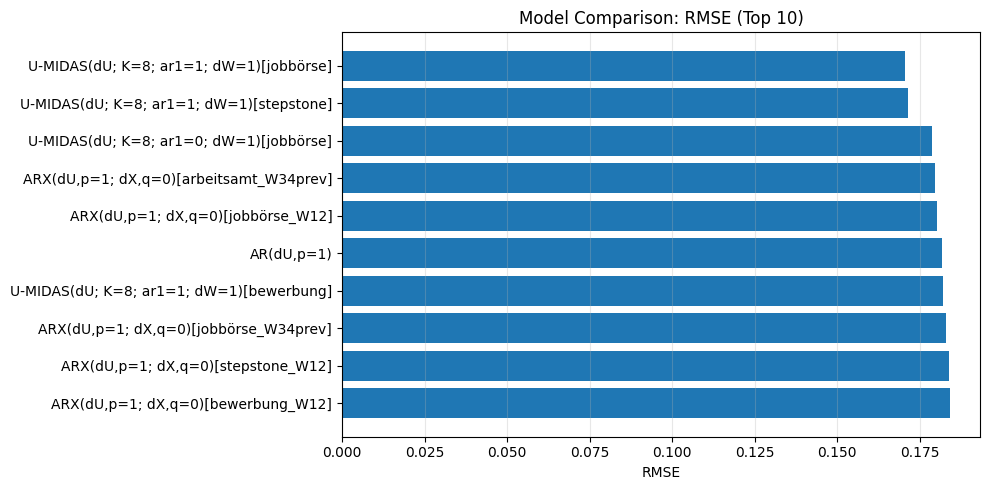

In [48]:
def plot_rmse_bar(leaderboard: pd.DataFrame, top_n: int = 10, title: str = None):
    top = leaderboard.head(top_n).iloc[::-1]
    plt.figure(figsize=(10, 5))
    plt.barh(top["model"], top["RMSE"])
    plt.xlabel("RMSE")
    plt.title(title or f"Model Comparison: RMSE (Top {top_n})")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

plot_rmse_bar(leaderboard, top_n=10)

## Best models plotted 

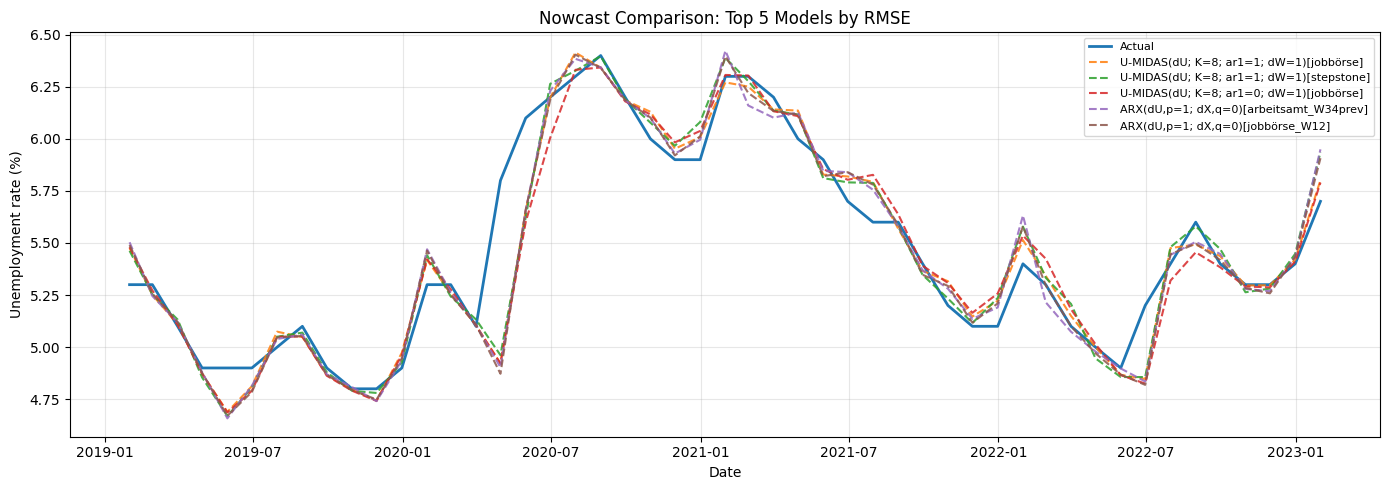

In [89]:
def plot_top_models(store: dict, leaderboard: pd.DataFrame, top_k: int = 5, title: str = None):
    top_models = leaderboard.head(top_k)["model"].tolist()
    base_act = store[top_models[0]]["act"]

    df = pd.DataFrame({"Actual": base_act})
    for m in top_models:
        df[m] = store[m]["pred"].reindex(base_act.index)

    plt.figure(figsize=(14, 5))
    plt.plot(df.index, df["Actual"], linewidth=2, label="Actual")
    for m in top_models:
        plt.plot(df.index, df[m], linestyle="--", label=m, alpha=0.85)
    plt.title(title or f"Nowcast Comparison: Top {top_k} Models by RMSE")
    plt.xlabel("Date"); plt.ylabel("Unemployment rate (%)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_top_models(store, leaderboard, top_k=5)

## Error diagnostic

In [90]:
def plot_abs_error_comparison(store, model_ar, model_midas, title=None):
    # Align on common support
    err_ar = store[model_ar]["err"]
    err_midas = store[model_midas]["err"]
    idx = err_ar.dropna().index.intersection(err_midas.dropna().index)

    df = pd.DataFrame({
        "AR(1)": err_ar.loc[idx].abs(),
        "U-MIDAS (jobbörse, ar1=1)": err_midas.loc[idx].abs()
    })

    plt.figure(figsize=(13, 4))
    plt.plot(df.index, df["AR(1)"], linestyle="--", label="|Error| AR(1)", alpha=0.85)
    plt.plot(df.index, df["U-MIDAS (jobbörse, ar1=1)"],
             linestyle="-", label="|Error| U-MIDAS", linewidth=2)

    plt.xlabel("Date")
    plt.ylabel("Absolute forecast error (percentage points)")
    plt.title(title or "Absolute forecast errors: AR vs U-MIDAS")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


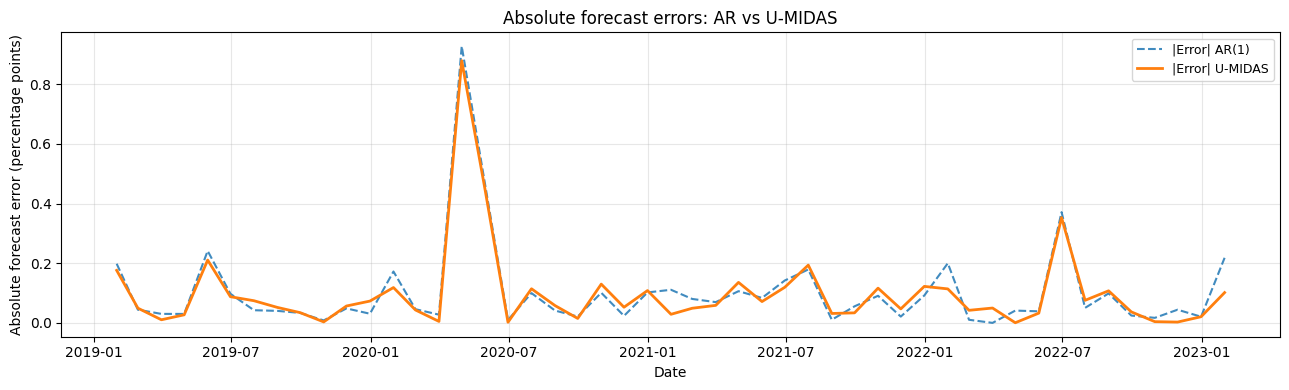

In [91]:
plot_abs_error_comparison(
    store,
    model_ar="AR(dU,p=1)",
    model_midas="U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse]"
)


# 6. MIDAS eligibility check: verifying the information set used for each monthly nowcast

This diagnostic block is a consistency check for the U-MIDAS construction. It verifies, month by month, that the weekly Google Trends information used to build the MIDAS regressors is available *strictly before* the assumed information cutoff date.

The report answers two practical questions:
1. **Do we have at least \(K\) weekly observations available prior to the cutoff?** (so a MIDAS row can be formed)
2. **Is the “most recent weekly lag” (`wlag0`) truly observed before the cutoff?** (so the nowcast does not use future information)




In [49]:
import pandas as pd
import numpy as np

def midas_eligibility_report(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    K: int = 8,
    target_transform: str = "diff",   # "diff" or "level"
    weekly_transform: str = "diff",   # "diff" or "level"
    cutoff_dates: pd.Series | None = None,
    cutoff_inclusive: bool = True,    # kept for completeness; your build uses -1s anyway
    subtract_one_second: bool = True  # mirrors your c_t_minus trick
) -> pd.DataFrame:
    # weekly series
    wk = weekly_panel[[gt_col]].copy().sort_index()
    wk.index = pd.to_datetime(wk.index).tz_localize(None)

    # monthly target index as month-end
    U = unemp_monthly.copy().sort_index()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    y = U.diff() if target_transform == "diff" else U

    x_raw = wk[gt_col]
    x = x_raw.diff() if weekly_transform == "diff" else x_raw

    # cutoff series aligned to month-end index
    if cutoff_dates is not None:
        cd = cutoff_dates.copy()
        cd.index = pd.to_datetime(cd.index).tz_localize(None).to_period("M").to_timestamp("M")
        cd = cd.sort_index()
    else:
        cd = None

    rows = []
    for t in y.index:
        y_val = y.loc[t]
        if pd.isna(y_val):
            continue

        # cutoff date for this month
        if cd is not None and t in cd.index and pd.notna(cd.loc[t]):
            c_t = pd.to_datetime(cd.loc[t]).tz_localize(None)
        else:
            c_t = t

        # apply "just before cutoff" (your approach)
        if subtract_one_second:
            c_eff = c_t - pd.Timedelta(seconds=1)
        else:
            c_eff = c_t

        # available x up to cutoff (your build uses <= c_eff)
        x_up_to = x.loc[x.index <= c_eff].dropna()
        n_avail = int(len(x_up_to))

        ok = n_avail >= K
        if ok:
            lastK = x_up_to.iloc[-K:]        # oldest..newest
            used_dates = lastK.index
            wlag0_date = used_dates[-1]      # newest
            wlag_last_date = used_dates[0]   # oldest
            violates = (wlag0_date > c_eff)  # should be False
            gap_days = (c_eff - wlag0_date).days
        else:
            used_dates = pd.DatetimeIndex([])
            wlag0_date = pd.NaT
            wlag_last_date = pd.NaT
            violates = False
            gap_days = np.nan

        rows.append({
            "t_month_end": t,
            "cutoff_raw": c_t,
            "cutoff_effective": c_eff,
            "n_weekly_available": n_avail,
            "K": K,
            "eligible": ok,
            "wlag0_date_newest_week": wlag0_date,
            "wlagKminus1_date_oldest_week": wlag_last_date,
            "gap_days_cutoff_minus_wlag0": gap_days,
            "violates_cutoff": violates,
            "used_week_dates": list(used_dates)  # for inspection
        })

    out = pd.DataFrame(rows).set_index("t_month_end").sort_index()
    return out


In [50]:
rep = midas_eligibility_report(
    weekly_panel=weekly_panel,
    unemp_monthly=panel["Unemp"],
    gt_col="stepstone",
    K=8,
    target_transform="diff",
    weekly_transform="diff",
    cutoff_dates=cutoff_release,   # oder cutoff_stichtag
    subtract_one_second=True
)

rep[["eligible","n_weekly_available","cutoff_effective","wlag0_date_newest_week","violates_cutoff"]].tail(12)


,eligible,n_weekly_available,cutoff_effective,wlag0_date_newest_week,violates_cutoff
t_month_end,,,,,
2022-02-28,True,565,2022-03-01 23:59:59,2022-02-27,False
2022-03-31,True,569,2022-03-30 23:59:59,2022-03-27,False
2022-04-30,True,574,2022-05-02 23:59:59,2022-05-01,False
2022-05-31,True,578,2022-05-30 23:59:59,2022-05-29,False
2022-06-30,True,582,2022-06-29 23:59:59,2022-06-26,False
2022-07-31,True,586,2022-07-28 23:59:59,2022-07-24,False
2022-08-31,True,591,2022-08-30 23:59:59,2022-08-28,False
2022-09-30,True,595,2022-09-29 23:59:59,2022-09-25,False
2022-10-31,True,600,2022-11-01 23:59:59,2022-10-30,False


For the last 12 months shown, the table confirms:

- `eligible = True` throughout, meaning there are enough weekly observations available to construct \(K=8\) weekly lags for each month.
- `violates_cutoff = False` throughout, which is the key result: the newest weekly observation used (`wlag0_date_newest_week`) always falls on or before the effective cutoff date.
- The effective cutoff dates (`cutoff_effective`) are slightly before the raw cutoff (minus one second), matching the logic in the U-MIDAS design builder that enforces a strict “available before cutoff” rule.

Overall, this confirms that the U-MIDAS design matrix respects the intended real-time information set and does not leak weekly data from after the cutoff into the monthly nowcasts.






# 7. Robustness Analysis

I assess the sensitivity to the MIDAS lag length K, which determines how much weekly history is used to predict monthly unemployment. The baseline specification fixes K = 8, corresponding to approximately two months of weekly information.

Because the appropriate memory length of search intensity is not known a priori and longer lag structures increase the risk of overparameterization, I re-estimate the U-MIDAS specification for K ∈{4,6,8,10}as a sensitivity analysis. 

In [51]:
umidas_K_table, storeK = run_umidas_K_robustness(
    weekly_panel=weekly_panel,
    panel=panel,
    cfg=cfg,
    Ks=(4, 6, 8, 10),
    include_ar1=True,
    cutoff_dates=cutoff_release
)

umidas_K_table


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_85243/3100049877.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  yhat = float(res.predict(X_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_85243/3100049877.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  yhat = float(res.predict(X_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_85243/3100049877.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  yhat = float(res.predict(X_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_85243/3100049877.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) inste

,keyword,K,ar1,RMSE,MAE,n
0,arbeitsamt,4,1,0.180995,0.103750,49
1,arbeitsamt,6,1,0.190894,0.105764,49
2,arbeitsamt,8,1,0.196627,0.107626,49
3,arbeitsamt,10,1,0.200124,0.111017,49
4,bewerbung,6,1,0.178765,0.105910,49
5,bewerbung,4,1,0.181737,0.106482,49
6,bewerbung,8,1,0.182061,0.110481,49
7,bewerbung,10,1,0.183881,0.114495,49
8,indeed,4,1,0.178910,0.107458,49
9,indeed,6,1,0.183545,0.107441,49


In [52]:
pivotK = umidas_K_table.pivot_table(index="keyword", columns="K", values="RMSE")
pivotK


K,4,6,8,10
keyword,,,,
arbeitsamt,0.180995,0.190894,0.196627,0.200124
bewerbung,0.181737,0.178765,0.182061,0.183881
indeed,0.178910,0.183545,0.187688,0.192854
jobbörse,0.182900,0.172506,0.170526,0.171870
stepstone,0.181557,0.180454,0.171413,0.176115


Three patterns here are to be observed. 
- First, forecast performance is not uniform across lag lengths, and the sensitivity differs by keyword: for jobbörse and stepstone, accuracy
improves as additional weekly lags are included, with the lowest RMSE attained at K = 8
within the examined range; for arbeitsamt and indeed, shorter lag windows perform better
and accuracy deteriorates as K increases. 

- Second, this heterogeneity is economically informative, indicating that the predictive content of Google search activity differs not
only in strength but also in temporal persistence: some keywords appear to contain
information distributed over several weeks, whereas others exhibit shorter-lived signals
that are increasingly diluted by noise when longer lag structures are imposed. 

- Third, while alternative lag lengths can yield marginal improvements for specific keywords, the
magnitude of these differences is modest and does not overturn the overall ranking of
models or the central conclusion that weekly Google Trends data provide only limited
incremental nowcasting gains. In this sense, the baseline choice K = 8 performs robustly
among the better-performing keywords while avoiding unnecessary parameter proliferation.

Overall, the lag-length sensitivity results show that the U-MIDAS findings are not driven
by an arbitrary choice of K or by overparameterization, but reflect modest and keyword-
dependent information content in weekly Google Trends data.

In [53]:
def add_delta_vs_baseline(df: pd.DataFrame, baseline_K: int = 8) -> pd.DataFrame:
    base = df[df["K"] == baseline_K][["keyword", "RMSE"]].rename(columns={"RMSE": "RMSE_baseline"})
    out = df.merge(base, on="keyword", how="left")
    out["ΔRMSE_vs_K" + str(baseline_K)] = out["RMSE"] - out["RMSE_baseline"]
    out["ΔRMSE_%"] = 100.0 * out["ΔRMSE_vs_K" + str(baseline_K)] / out["RMSE_baseline"]
    return out

umidas_K_table2 = add_delta_vs_baseline(umidas_K_table, baseline_K=8)
umidas_K_table2.sort_values(["keyword", "K"])


,keyword,K,ar1,RMSE,MAE,n,RMSE_baseline,ΔRMSE_vs_K8,ΔRMSE_%
0,arbeitsamt,4,1,0.180995,0.103750,49,0.196627,-0.015633,-7.950397
1,arbeitsamt,6,1,0.190894,0.105764,49,0.196627,-0.005733,-2.915631
2,arbeitsamt,8,1,0.196627,0.107626,49,0.196627,0.000000,0.000000
3,arbeitsamt,10,1,0.200124,0.111017,49,0.196627,0.003497,1.778277
5,bewerbung,4,1,0.181737,0.106482,49,0.182061,-0.000324,-0.178013
4,bewerbung,6,1,0.178765,0.105910,49,0.182061,-0.003296,-1.810262
6,bewerbung,8,1,0.182061,0.110481,49,0.182061,0.000000,0.000000
7,bewerbung,10,1,0.183881,0.114495,49,0.182061,0.001820,0.999436
8,indeed,4,1,0.178910,0.107458,49,0.187688,-0.008778,-4.676845
9,indeed,6,1,0.183545,0.107441,49,0.187688,-0.004143,-2.207540


# 7.1 Penalized U-MIDAS comparison: ridge and lasso as shrinkage benchmarks

This block runs a focused “mini-horserace” restricted to the penalized U-MIDAS variants. For each keyword and for both specification choices (with and without an AR term), the code estimates:

- **Ridge U-MIDAS (partial-out dummies)** and
- **Lasso U-MIDAS (partial-out dummies)**

and evaluates them on the same out-of-sample window as the main horserace. The output is a ranked leaderboard (RMSE, MAE) plus a store of the underlying prediction and error series for further diagnostics.


In [54]:
def run_penalized_umidas_only(panel: pd.DataFrame, weekly_panel: pd.DataFrame, cfg, K=8):
    results = []
    weekly_keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]

    for kw in weekly_keywords:
        for arflag in [False, True]:
            # Ridge
            pred, act = nowcast_umidas_penalized_partialout(
                weekly_panel=weekly_panel,
                unemp_monthly=panel["Unemp"],
                gt_col=kw,
                start_eval=cfg.eval_start,
                K=K,
                include_ar1=arflag,
                target_transform="diff",
                weekly_transform="diff",
                seasonal_dummies=cfg.seasonal_dummies,
                min_train=cfg.min_train,
                model="ridge",
                alphas=(1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0),
                cv_splits=5,
                refit_alpha_each_t=True
            )
            name = f"RIDGE-U-MIDAS-PO(dU; K={K}; ar1={int(arflag)}; dW=1)[{kw}]"
            results.append((name, pred, act))

            # Lasso
            pred, act = nowcast_umidas_penalized_partialout(
                weekly_panel=weekly_panel,
                unemp_monthly=panel["Unemp"],
                gt_col=kw,
                start_eval=cfg.eval_start,
                K=K,
                include_ar1=arflag,
                target_transform="diff",
                weekly_transform="diff",
                seasonal_dummies=cfg.seasonal_dummies,
                min_train=cfg.min_train,
                model="lasso",
                alphas=(1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1),
                cv_splits=5,
                refit_alpha_each_t=True
            )
            name = f"LASSO-U-MIDAS-PO(dU; K={K}; ar1={int(arflag)}; dW=1)[{kw}]"
            results.append((name, pred, act))

    # Build leaderboard
    rows = []
    store = {}
    for name, pred, act in results:
        pred, act = pred.align(act, join="inner")
        err = pred - act
        m = compute_metrics(pred, act)
        rows.append({"model": name, **m})
        store[name] = {"pred": pred, "act": act, "err": err}

    leaderboard = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    return leaderboard, store


In [55]:
leaderboard_pen, store_pen = run_penalized_umidas_only(panel, weekly_panel, cfg, K=8)
leaderboard_pen.head(20)


,model,RMSE,MAE,n
0,RIDGE-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[stepstone],0.175239,0.102043,49
1,RIDGE-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[jobbörse],0.179163,0.102265,49
2,LASSO-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[stepstone],0.181495,0.103791,49
3,LASSO-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[jobbörse],0.182498,0.102547,49
4,LASSO-U-MIDAS-PO(dU; K=8; ar1=0; dW=1)[stepstone],0.184002,0.109886,49
5,RIDGE-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[bewerbung],0.185935,0.112297,49
6,RIDGE-U-MIDAS-PO(dU; K=8; ar1=0; dW=1)[stepstone],0.186378,0.109665,49
7,RIDGE-U-MIDAS-PO(dU; K=8; ar1=0; dW=1)[jobbörse],0.186481,0.109900,49
8,LASSO-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[bewerbung],0.188563,0.111066,49
9,LASSO-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[arbeits...,0.189077,0.110102,49


### Interpretation of the leaderboard

1. **Ridge dominates lasso in this setting.**  
   The best penalized models are ridge-based, while the top lasso models are generally weaker and often close to the AR benchmark range. This suggests that the signal is diffuse across weekly lags and benefits more from shrinkage than from hard variable selection.

2. **Including the AR term remains important.**  
   For the best-performing keywords, the strongest penalized results occur with `ar1=1`. This is consistent with the main (unpenalized) U-MIDAS results: the weekly signal works best when combined with monthly persistence in \(\Delta U_t\).

3. **Penalization does not outperform the best unpenalized U-MIDAS models.**  
   Compare the top penalized model here (ridge, stepstone, ar1=1; RMSE ≈ 0.1752) to the best unpenalized U-MIDAS(with AR) from the main horserace (jobbörse/stepstone around RMSE ≈ 0.1705–0.1714). Penalization improves stability but does not deliver a further accuracy gain in this application.

4. **Keyword heterogeneity persists.**  
   The same pattern as before remains visible: stepstone and jobbörse are the strongest keywords, while indeed and arbeitsamt are relatively weak even under shrinkage. This indicates that the performance differences are not primarily driven by overfitting to high-dimensional weekly lags, but by genuine differences in signal content across keywords.


### Diagnostic: stability of the AR(1) coefficient in the expanding-window benchmark

This block is a parameter-stability check for the AR benchmark. Since the AR model is re-estimated each month in the expanding-window nowcasting loop, I track how the estimated AR(1) coefficient evolves over the evaluation period. This helps assess whether the persistence in the differenced unemployment series is broadly stable or whether it shifts over time (which could matter for forecast performance and model comparisons).


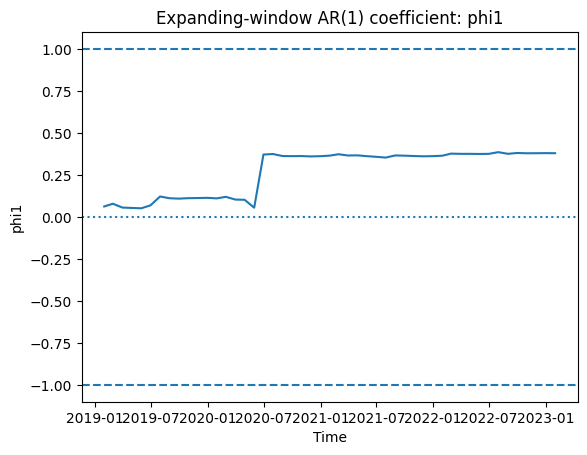

In [60]:
import matplotlib.pyplot as plt

phi_series = phi_series.sort_index()

plt.figure()
plt.plot(phi_series.index, phi_series.values)
plt.axhline(1.0, linestyle="--")
plt.axhline(-1.0, linestyle="--")
plt.axhline(0.0, linestyle=":")
plt.title("Expanding-window AR(1) coefficient: phi1")
plt.xlabel("Time")
plt.ylabel("phi1")
plt.show()


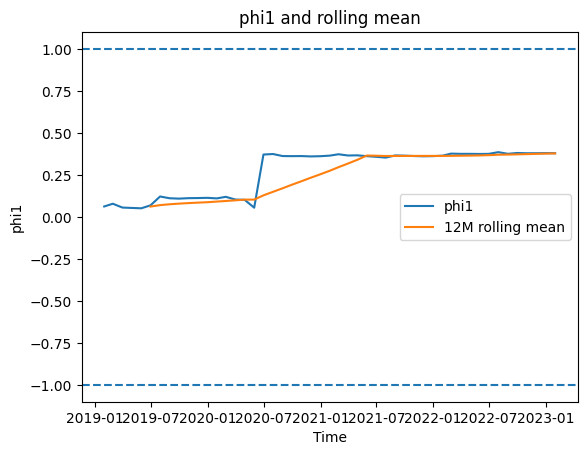

In [61]:
roll = phi_series.rolling(window=12, min_periods=6).mean()

plt.figure()
plt.plot(phi_series.index, phi_series.values, label="phi1")
plt.plot(roll.index, roll.values, label="12M rolling mean")
plt.axhline(1.0, linestyle="--")
plt.axhline(-1.0, linestyle="--")
plt.title("phi1 and rolling mean")
plt.xlabel("Time")
plt.ylabel("phi1")
plt.legend()
plt.show()


### Stability and Evolution of the AR(1) Benchmark

To assess the adequacy of the autoregressive benchmark estimated by OLS, the AR(1) coefficient in first differences is tracked across expanding estimation windows. The estimated coefficient remains comfortably inside the unit circle throughout the evaluation period, with values well below unity. This indicates that the short-run dynamics of monthly unemployment changes are stable and non-explosive.

The coefficient exhibits a smooth evolution over time rather than abrupt fluctuations. In particular, the degree of persistence increases around mid-2020 and subsequently stabilizes at a moderate level. This pattern is economically plausible and consistent with heightened persistence in labor market adjustments during and after the COVID-19 period, while not suggesting any loss of stability in the autoregressive structure.

Overall, these diagnostics support the use of a simple AR(1) model in first differences as a well-behaved and credible benchmark for the nowcasting exercise.


# 8. A deeper look in the the biweekly models

Before conducting a Diebold Mariano Test I tak a glimpse how the to best performing ARX models nowacst the german unemployment.
That for the two best performing models for the two respective timeframes are chosen and evaluated.

The best models are :

- ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]	

- ARX(dU,p=1; dX,q=0)[jobbörse_W12]	0.1


In [62]:
def best_arx_model(leaderboard, scheme: str) -> str:
    mask = (
        leaderboard["model"].str.contains("ARX", case=False) &
        leaderboard["model"].str.contains(scheme, case=False)
    )
    return leaderboard.loc[mask].iloc[0]["model"]

best_w12 = best_arx_model(leaderboard, "W12")
best_w34 = best_arx_model(leaderboard, "W34prev")

best_w12, best_w34

def common_support(store, models):
    idx = None
    for m in models:
        s = store[m]["pred"].dropna().index.intersection(
            store[m]["act"].dropna().index
        )
        idx = s if idx is None else idx.intersection(s)
    return idx


In [63]:
def plot_actual_vs_w12_w34(store, leaderboard, title=None):
    best_w12 = best_arx_model(leaderboard, "W12")
    best_w34 = best_arx_model(leaderboard, "W34prev")

    models = [best_w12, best_w34]
    idx = common_support(store, models)

    act = store[models[0]]["act"].reindex(idx)
    w12 = store[best_w12]["pred"].reindex(idx)
    w34 = store[best_w34]["pred"].reindex(idx)

    df = pd.DataFrame({
        "Actual": act,
        "ARX–W12": w12,
        "ARX–W34prev": w34
    }).dropna()

    plt.figure(figsize=(13,4))
    plt.plot(df.index, df["Actual"], linewidth=2.2, label="Actual")
    plt.plot(df.index, df["ARX–W12"], linestyle="--", label=f"Best ARX W12")
    plt.plot(df.index, df["ARX–W34prev"], linestyle=":", label=f"Best ARX W34prev")
    plt.xlabel("Date")
    plt.ylabel("Unemployment rate (%)")
    plt.title(title or "Actual unemployment vs best ARX nowcasts (W12 vs W34prev)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


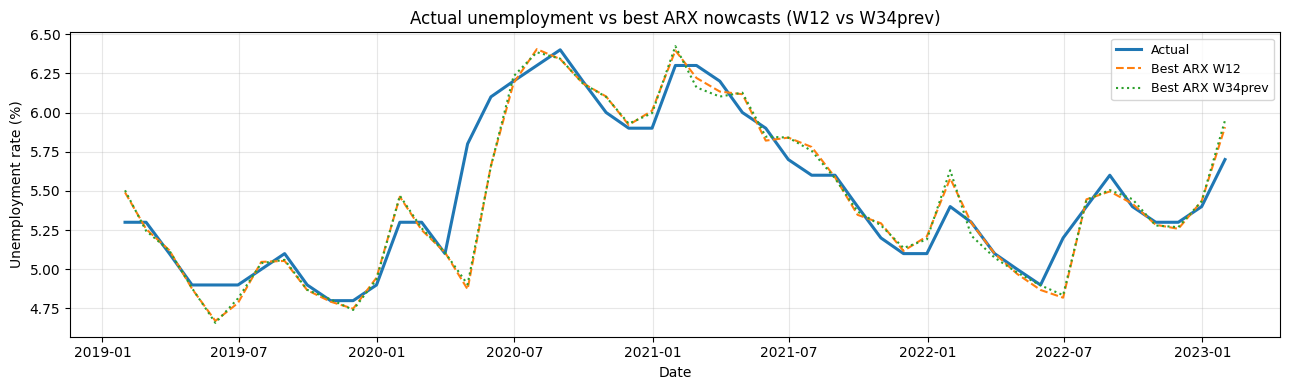

In [64]:
plot_actual_vs_w12_w34(store, leaderboard)


## 8.2 Comparing the errors of both

In [65]:
def plot_abs_error_w12_vs_w34(store, leaderboard, title=None):
    # identify best models
    best_w12 = best_arx_model(leaderboard, "W12")
    best_w34 = best_arx_model(leaderboard, "W34prev")

    models = [best_w12, best_w34]
    idx = common_support(store, models)

    # absolute errors on common support
    e_w12 = store[best_w12]["err"].reindex(idx).abs()
    e_w34 = store[best_w34]["err"].reindex(idx).abs()

    df = pd.DataFrame({
        "ARX–W12": e_w12,
        "ARX–W34prev": e_w34
    }).dropna()

    plt.figure(figsize=(13,4))
    plt.plot(df.index, df["ARX–W12"], linestyle="--", label="|Error| Best ARX W12")
    plt.plot(df.index, df["ARX–W34prev"], linestyle=":", label="|Error| Best ARX W34prev")
    plt.xlabel("Date")
    plt.ylabel("Absolute forecast error (pp)")
    plt.title(title or "Absolute forecast errors: Best ARX W12 vs W34prev")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


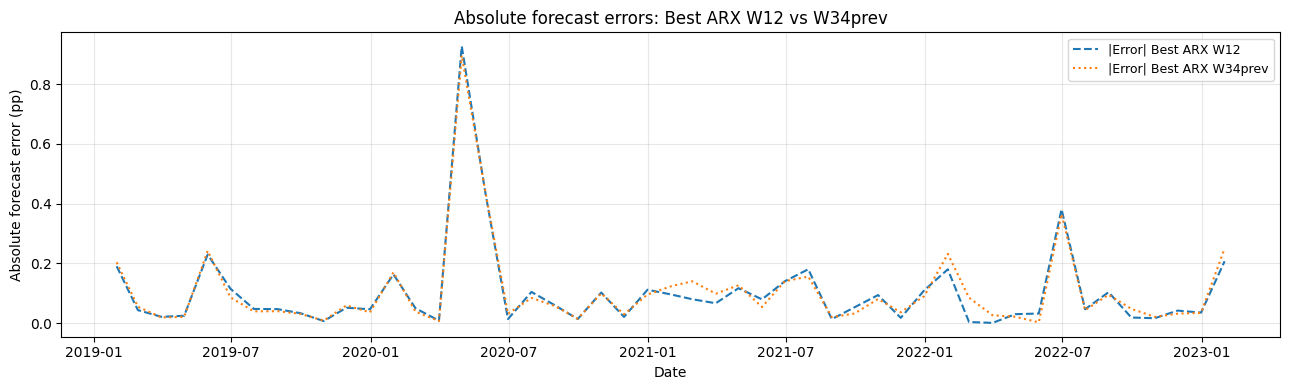

In [66]:
plot_abs_error_w12_vs_w34(store, leaderboard)


based on the plots the both predictions such as the error plots nearly look indistuigishable.
It cannot be claimed from the first visual inspection that either one of the models performs better then the other. The signal that the Google Trend variables exhibit appears to be weak.

# 9. Comparing biweekly information timing in ARX models (W12 vs W34prev)

This block extracts the ARX models that use biweekly Google Trends aggregations and summarizes whether forecasting performance depends on *when* the search information is taken from. The goal is to compare the two timing schemes used in the thesis:

- `W12`: aggregation based on weeks 1–2 of the current month
- `W34prev`: aggregation based on weeks 3–4 of the previous month

The code parses model names from the horserace leaderboard, identifies the keyword and timing scheme, and then produces a compact table comparing RMSE under both schemes for each keyword.


In [ ]:

import re

def extract_scheme_and_keyword(model_name: str):

    model_name = str(model_name)

    if "W12" in model_name:
        scheme = "W12"
    elif "W34prev" in model_name:
        scheme = "W34prev"
    else:
        return None, None

    # Prefer token inside [...]
    m = re.search(r"\[(.*?)\]", model_name)
    token = m.group(1) if m else model_name

    # Remove scheme suffixes
    token = token.replace("_W12", "").replace("_W34prev", "")

    # Keep only word-ish characters incl. German umlauts
    token = re.sub(r"[^\wäöüÄÖÜß]+", "", token)

    keyword = token if token else None
    return keyword, scheme


def list_arx_biweekly_models(leaderboard: pd.DataFrame) -> pd.DataFrame:

    if "model" not in leaderboard.columns:
        raise ValueError("leaderboard must contain a 'model' column.")
    s = leaderboard["model"].astype(str)
    mask = s.str.contains("ARX", case=False, na=False) & (
        s.str.contains("W12", na=False) | s.str.contains("W34prev", na=False)
    )
    return leaderboard.loc[mask].copy()



In [ ]:
def summarize_w12_vs_w34(leaderboard: pd.DataFrame) -> pd.DataFrame:

    arx = list_arx_biweekly_models(leaderboard).copy()
    if arx.empty:
        raise ValueError("No ARX biweekly models found in leaderboard['model'].")

    arx["keyword"], arx["scheme"] = zip(*arx["model"].map(extract_scheme_and_keyword))
    arx = arx.dropna(subset=["keyword", "scheme"])

    pivot = (arx.pivot_table(index="keyword", columns="scheme", values="RMSE", aggfunc="min")
               .sort_index())

    if "W12" in pivot.columns and "W34prev" in pivot.columns:
        pivot["ΔRMSE(W12−W34prev)"] = pivot["W12"] - pivot["W34prev"]
        pivot = pivot.sort_values("ΔRMSE(W12−W34prev)")

    return pivot

biweekly_rmse = summarize_w12_vs_w34(leaderboard)
biweekly_rmse


scheme,W12,W34prev,ΔRMSE(W12−W34prev)
keyword,,,
stepstone,0.183697,0.189458,-0.005761
indeed,0.186145,0.190788,-0.004644
bewerbung,0.183999,0.187247,-0.003248
jobbörse,0.180184,0.182754,-0.002570
arbeitsamt,0.184427,0.179524,0.004903


For most keywords, `W12` delivers a lower RMSE than `W34prev` (negative values of ΔRMSE), indicating that using information from the first two weeks of the current month is slightly more helpful than relying on late information from the previous month.

The exception is `arbeitsamt`, where `W34prev` performs better (positive ΔRMSE). This suggests that for this particular keyword, earlier-month information (from late in the previous month) aligns more closely with the unemployment changes being forecasted.

Overall, the timing effects are modest in magnitude, but the table provides a clear and systematic way to document whether the choice of biweekly aggregation window matters for forecast accuracy.


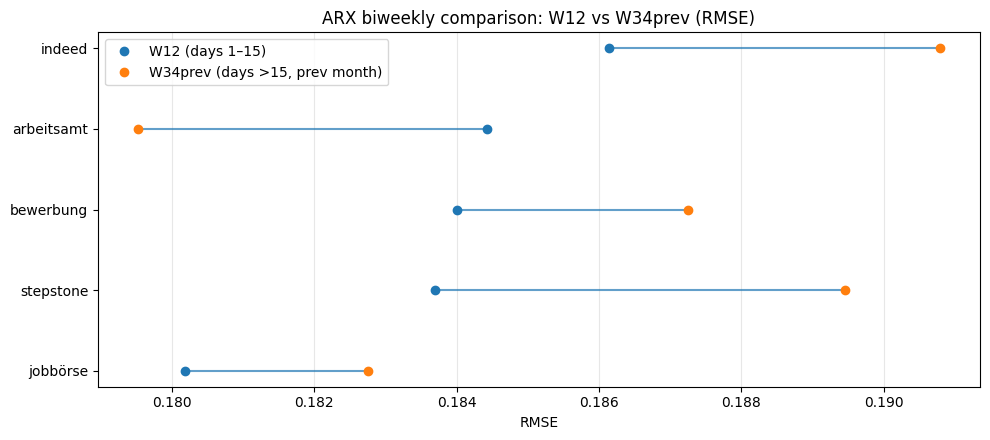

In [75]:
def plot_dumbbell_w12_w34(biweekly_rmse: pd.DataFrame, title: str = None):
    if not {"W12", "W34prev"}.issubset(biweekly_rmse.columns):
        raise ValueError("Need both W12 and W34prev columns in biweekly_rmse.")

    df = biweekly_rmse[["W12", "W34prev"]].dropna().copy()
    df = df.sort_values("W12")  # ordering choice; change if you want

    y = np.arange(len(df))
    plt.figure(figsize=(10, 0.5*len(df) + 2))
    plt.hlines(y=y, xmin=df["W12"], xmax=df["W34prev"], alpha=0.7)
    plt.plot(df["W12"], y, marker="o", linestyle="None", label="W12 (days 1–15)")
    plt.plot(df["W34prev"], y, marker="o", linestyle="None", label="W34prev (days >15, prev month)")

    plt.yticks(y, df.index)
    plt.xlabel("RMSE")
    plt.title(title or "ARX biweekly comparison: W12 vs W34prev (RMSE)")
    plt.grid(True, alpha=0.3, axis="x")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_dumbbell_w12_w34(biweekly_rmse)


In [ ]:
def map_keyword_to_models(leaderboard: pd.DataFrame) -> pd.DataFrame:
    arx = list_arx_biweekly_models(leaderboard).copy()
    if arx.empty:
        raise ValueError("No ARX biweekly models found.")

    arx["keyword"], arx["scheme"] = zip(*arx["model"].map(extract_scheme_and_keyword))
    arx = arx.dropna(subset=["keyword", "scheme"])

    # best model per keyword x scheme
    arx = arx.sort_values("RMSE").drop_duplicates(["keyword", "scheme"], keep="first")
    wide = arx.pivot(index="keyword", columns="scheme", values="model")

    return wide

kw_models_main = map_keyword_to_models(leaderboard)
kw_models_main

scheme,W12,W34prev
keyword,,
arbeitsamt,"ARX(dU,p=1; dX,q=0)[arbeitsamt_W12]","ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]"
bewerbung,"ARX(dU,p=1; dX,q=0)[bewerbung_W12]","ARX(dU,p=1; dX,q=0)[bewerbung_W34prev]"
indeed,"ARX(dU,p=1; dX,q=0)[indeed_W12]","ARX(dU,p=1; dX,q=0)[indeed_W34prev]"
jobbörse,"ARX(dU,p=1; dX,q=0)[jobbörse_W12]","ARX(dU,p=1; dX,q=0)[jobbörse_W34prev]"
stepstone,"ARX(dU,p=1; dX,q=0)[stepstone_W12]","ARX(dU,p=1; dX,q=0)[stepstone_W34prev]"


### Diebold–Mariano tests for timing comparisons (W12 vs W34prev) in non-nested ARX models

This block implements and applies the Diebold–Mariano (DM) test to compare forecast accuracy between the two biweekly timing schemes used in the ARX models. 

The implementation uses a Newey–West lag length of zero, which corresponds to heteroskedasticity-robust inference without autocorrelation correction and is consistent with one-step-ahead monthly nowcasts. A Harvey–Leybourne–Newbold small-sample correction is applied, and p-values are computed from a Student-\(t\) reference distribution.


In [77]:
from scipy import stats
# -----------------------------
# 3) DM test with Newey–West lag length = 0 (heteroskedasticity-robust)
# -----------------------------
def dm_test_paired_lag0(
    e1: pd.Series,
    e2: pd.Series,
    loss: str = "mse",
    small_sample: bool = True,
    alternative: str = "two-sided"
) -> dict:
    """
    Diebold–Mariano test with NW lag length = 0.
    This implies heteroskedasticity-robust inference without autocorrelation correction.
    """
    df = pd.concat([e1.rename("e1"), e2.rename("e2")], axis=1).dropna()
    T = int(df.shape[0])

    if T < 10:
        return {"T": T, "mean_d": np.nan, "dm_stat": np.nan, "pvalue": np.nan, "hac_lags": 0, "loss": loss, "h": 1}

    if loss.lower() == "mse":
        d = df["e1"].to_numpy()**2 - df["e2"].to_numpy()**2
    elif loss.lower() == "mae":
        d = np.abs(df["e1"].to_numpy()) - np.abs(df["e2"].to_numpy())
    else:
        raise ValueError("loss must be 'mse' or 'mae'.")

    mean_d = float(np.mean(d))
    var_d = float(np.var(d, ddof=1)) # this makes the big difference to the function before 
    var_mean = var_d / T if T > 1 else np.nan

    if not np.isfinite(var_mean) or var_mean <= 0:
        return {"T": T, "mean_d": mean_d, "dm_stat": np.nan, "pvalue": np.nan, "hac_lags": 0, "loss": loss.lower(), "h": 1}

    dm = mean_d / np.sqrt(var_mean)

    # HLN small-sample correction; for h=1 => sqrt((T-1)/T)
    if small_sample:
        dm *= float(np.sqrt((T - 1) / T))

    dfree = T - 1
    if alternative == "two-sided":
        p = 2.0 * (1.0 - stats.t.cdf(abs(dm), df=dfree))
    elif alternative == "less":
        p = stats.t.cdf(dm, df=dfree)
    elif alternative == "greater":
        p = 1.0 - stats.t.cdf(dm, df=dfree)
    else:
        raise ValueError("alternative must be 'two-sided', 'less', or 'greater'.")

    return {"T": T, "mean_d": mean_d, "dm_stat": float(dm), "pvalue": float(p),
            "hac_lags": 0, "loss": loss.lower(), "h": 1}


# -----------------------------
# 4) Run W12 vs W34prev DM tests across keywords
# -----------------------------
def dm_biweekly_all_keywords_lag0(
    store: dict,
    kw_models: pd.DataFrame,
    loss: str = "mse",
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    For each keyword, compares W12 vs W34prev via DM (lag=0).
    Requires store[model_name]['err'].
    """
    rows = []
    for keyword in kw_models.index:
        m12 = kw_models.loc[keyword].get("W12", None)
        m34 = kw_models.loc[keyword].get("W34prev", None)

        if pd.isna(m12) or pd.isna(m34):
            continue
        if (m12 not in store) or (m34 not in store):
            continue

        e12 = store[m12]["err"]
        e34 = store[m34]["err"]

        res = dm_test_paired_lag0(e1=e12, e2=e34, loss=loss, small_sample=True, alternative="two-sided")

        # d = L(e_W12) - L(e_W34prev): mean_d < 0 => W12 lower loss
        winner = None
        if np.isfinite(res["mean_d"]):
            winner = "W12" if res["mean_d"] < 0 else "W34prev"

        rows.append({
            "keyword": keyword,
            "model_W12": m12,
            "model_W34prev": m34,
            **res,
            "winner_by_mean_loss": winner,
            "reject_equal_accuracy": bool(np.isfinite(res["pvalue"]) and (res["pvalue"] < alpha))
        })

    out = pd.DataFrame(rows).sort_values(["pvalue", "keyword"]).reset_index(drop=True)
    return out

In [78]:
kw_models = map_keyword_to_models(leaderboard)
dm_results_mse = dm_biweekly_all_keywords_lag0(store=store, kw_models=kw_models, loss="mse", alpha=0.05)
dm_results_mse


,keyword,model_W12,model_W34prev,T,mean_d,dm_stat,pvalue,hac_lags,loss,h,winner_by_mean_loss,reject_equal_accuracy
0,jobbörse,"ARX(dU,p=1; dX,q=0)[jobbörse_W12]","ARX(dU,p=1; dX,q=0)[jobbörse_W34prev]",49,-0.000933,-1.360136,0.180141,0,mse,1,W12,False
1,stepstone,"ARX(dU,p=1; dX,q=0)[stepstone_W12]","ARX(dU,p=1; dX,q=0)[stepstone_W34prev]",49,-0.002150,-1.274954,0.208463,0,mse,1,W12,False
2,arbeitsamt,"ARX(dU,p=1; dX,q=0)[arbeitsamt_W12]","ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]",49,0.001784,0.975175,0.334362,0,mse,1,W34prev,False
3,bewerbung,"ARX(dU,p=1; dX,q=0)[bewerbung_W12]","ARX(dU,p=1; dX,q=0)[bewerbung_W34prev]",49,-0.001206,-0.853063,0.397861,0,mse,1,W12,False
4,indeed,"ARX(dU,p=1; dX,q=0)[indeed_W12]","ARX(dU,p=1; dX,q=0)[indeed_W34prev]",49,-0.001750,-0.529726,0.598743,0,mse,1,W12,False


Across all keywords, the mean loss differentials are small and the DM p-values are well above 0.05. This implies that, at conventional levels, there is **no statistical evidence** that the W12 timing scheme and the W34prev timing scheme produce materially different forecast accuracy within the ARX class.

The sign of `mean_d` indicates which scheme performs better on average:
- Negative `mean_d` means W12 has lower average squared error than W34prev.
- Positive `mean_d` means W34prev has lower average squared error than W12.

In the results, W12 has a lower mean loss for four of the five keywords, while arbeitsamt favors W34prev. However, none of these differences are statistically significant, so the timing advantage should be interpreted as suggestive rather than decisive.


# Clark West test to compare forecast accuracy

In [80]:
import numpy as np
import pandas as pd
from scipy import stats

def clark_west_lag0(y_hat_0, y_hat_1, y_true, use_t=False):
    df = pd.concat([y_true.rename("y"),
                    y_hat_0.rename("y0"),
                    y_hat_1.rename("y1")], axis=1).dropna()
    T = len(df)
    e0 = df["y"] - df["y0"]
    e1 = df["y"] - df["y1"]

    f = e0**2 - e1**2 + (df["y1"] - df["y0"])**2
    fbar = f.mean()

    u = f - fbar
    var_mean = (u @ u) / (T**2)   # NW lag 0 for mean
    cw = fbar / np.sqrt(var_mean)

    if use_t:
        pval = 1.0 - stats.t.cdf(cw, df=T-1)
    else:
        pval = stats.norm.sf(cw)  # one-sided

    return {"T": T, "mean_f": float(fbar), "cw_stat": float(cw), "pvalue": float(pval)}



In [81]:
# Benchmark
model_ar = "AR(dU,p=1)"

# Challengers
model_arx = "ARX(dU,p=1; dX,q=0)[jobbörse_W12]"
model_umidas_job = "U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse]"
model_umidas_step = "U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]"


In [82]:
cw_results = []

def run_cw(name, model_large):
    res = clark_west_lag0(
        y_hat_0 = store[model_ar]["pred"],
        y_hat_1 = store[model_large]["pred"],
        y_true  = store[model_ar]["act"],
    )
    return {
        "comparison": f"{model_large} vs AR",
        **res
    }

cw_results.append(run_cw("ARX", model_arx))
cw_results.append(run_cw("U-MIDAS jobbörse", model_umidas_job))
cw_results.append(run_cw("U-MIDAS stepstone", model_umidas_step))

cw_table = pd.DataFrame(cw_results)
cw_table


,comparison,T,mean_f,cw_stat,pvalue
0,"ARX(dU,p=1; dX,q=0)[jobbörse_W12] vs AR",49,0.000620,1.191699,0.116690
1,U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse] vs AR,49,0.005349,2.310297,0.010436
2,U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone] vs AR,49,0.005070,1.470917,0.070657


To assess whether the observed RMSE reductions reflect genuine predictive gains rather than estimation noise, I apply the Clark–West (2007) test for nested forecast models. The benchmark is a monthly AR specification, while the competing models include a biweekly ARX model using Google Trends and U-MIDAS specifications incorporating weekly search data. The test is conducted under squared error loss using heteroskedasticity-robust inference with lag length zero and a one-sided alternative. Results indicate that while some Google Trends–based models marginally improve forecast accuracy relative to the AR benchmark, statistical evidence is generally weak and keyword-dependent.

## topics with regard to that
-- sample size 
The evaluation sample is necessarily limited by the availability of real-time Google Trends data. To mitigate small-sample concerns, I apply the Harvey–Leybourne–Newbold correction and interpret results cautiously, focusing on qualitative patterns rather than magnitude.

-- p values change with another loss functions
Squared error loss is standard in forecast evaluation and directly comparable to RMSE rankings. Alternative loss functions yield qualitatively similar rankings.

-- You selected the best MIDAS models before testing. Isn’t this data-mining
The MIDAS lag length was fixed ex ante based on a standard two-month window, and keyword choice reflects common labor-market search terms rather than ex post optimization.
Sensitivity analysis confirms that results are not driven by a particular lag choice.

-- The economic magnitude looks tiny (mean_f is small). Is this meaningful:
Given the high persistence of monthly unemployment, even small reductions in forecast error are economically meaningful and consistent with the nowcasting literature.

-- Why lag length 0? Why not HAC
With one-step-ahead non-overlapping forecasts, serial correlation in the loss differential is limited. Setting the Newey–West lag length to zero yields heteroskedasticity-robust inference without over-smoothing in a small sample.



Overall, the evidence suggests that weekly Google search activity provides modest but statistically detectable nowcasting gains for unemployment, whereas lower-frequency aggregations do not robustly outperform a simple autoregressive benchmark.



## Checking serial correlation in the loss differential

In [83]:
model_ar = "AR(dU,p=1)"
model_best = "U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse]"


In [84]:

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

# Align actuals and predictions
df = pd.concat(
    [
        store[model_ar]["act"].rename("y"),
        store[model_ar]["pred"].rename("y_ar"),
        store[model_best]["pred"].rename("y_best")
    ],
    axis=1
).dropna()

# Forecast errors
e_ar = df["y"] - df["y_ar"]
e_best = df["y"] - df["y_best"]


In [85]:
acf_ar = acf(e_ar, nlags=6, fft=False)
acf_best = acf(e_best, nlags=6, fft=False)

pd.DataFrame({
    "lag": range(len(acf_ar)),
    "ACF_AR": acf_ar,
    "ACF_Best_MIDAS": acf_best
})


,lag,ACF_AR,ACF_Best_MIDAS
0,0,1.000000,1.000000
1,1,0.252979,0.267524
2,2,-0.006794,0.004028
3,3,-0.110358,-0.091684
4,4,-0.093321,-0.078003
5,5,-0.078257,-0.069810
6,6,0.032094,-0.026979


In [86]:
lb_ar = acorr_ljungbox(e_ar, lags=[1, 2, 3, 4], return_df=True)
lb_best = acorr_ljungbox(e_best, lags=[1, 2, 3, 4], return_df=True)

lb_ar, lb_best


(    lb_stat  lb_pvalue
 1  3.331910   0.067948
 2  3.334364   0.188778
 3  3.995998   0.261897
 4  4.479629   0.344970,
     lb_stat  lb_pvalue
 1  3.726075   0.053569
 2  3.726938   0.155134
 3  4.183602   0.242309
 4  4.521490   0.340007)

In [87]:
# Clark–West loss differential f_t
f_t = e_ar**2 - (e_best**2 - (df["y_best"] - df["y_ar"])**2)


In [88]:
lb_f = acorr_ljungbox(f_t, lags=[1, 2, 3, 4], return_df=True)
lb_f


,lb_stat,lb_pvalue
1,0.048805,0.825156
2,0.389245,0.823145
3,0.392927,0.941700
4,0.716647,0.949260


Absolutely no evidence of serial correlation, p-values are extremely large
This directly validates:
- Newey–West lag length = 0
- heteroskedasticity-robust inference

As a diagnostic, I examine serial correlation in both forecast errors and in the Clark–West loss differential. While forecast errors exhibit mild autocorrelation at lag one for both the AR and MIDAS specifications, Ljung–Box tests applied to the Clark–West loss differential show no evidence of serial dependence at any lag. This supports the use of heteroskedasticity-robust inference with Newey–West lag length set to zero in the forecast comparison tests.